# PROJECT: E. Coli Detection from DNA — AutoML Classification

# Step-0
###Setup Environment (Colab Free Tier Safe)


In [141]:
import sys
import os
import random
import numpy as np


In [142]:
# detect if we're running on colab or locally
IS_COLAB = "google.colab" in sys.modules

print("Running on:", "Google Colab" if IS_COLAB else "Local machine")
print("Python version:", sys.version.split()[0])

Running on: Google Colab
Python version: 3.12.13


In [143]:
# mount google drive if on colab - all outputs go here
if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_PATH = "/content/drive/MyDrive/ecoli_dna_project"
else:
    BASE_PATH = os.path.join(os.getcwd(), "ecoli_dna_project")

print("Project folder:", BASE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/ecoli_dna_project


In [144]:
# install dependencies - order matters to avoid conflicts
if IS_COLAB:
    os.system("pip install -q ucimlrepo biopython")
    os.system("pip install -q lazypredict")
    os.system("pip install -q flaml")
    os.system("pip install -q shap")
    os.system("pip install -q gradio")
    print("packages installed")
else:
    print("run: pip install -r requirements.txt")

packages installed


In [147]:

# safe imports - know exactly what failed if something breaks
def try_import(name, cmd):
    try:
        exec(cmd, globals())
        return True
    except Exception as e:
        print(f"  failed to import {name}: {e}")
        return False

imports = {
    "numpy": "import numpy as np",
    "pandas": "import pandas as pd",
    "matplotlib": "import matplotlib.pyplot as plt",
    "seaborn": "import seaborn as sns",
    "sklearn": "import sklearn",
    "biopython": "import Bio",
    "ucimlrepo": "from ucimlrepo import fetch_ucirepo",
    "lazypredict": "from lazypredict.Supervised import LazyClassifier",
    "flaml": "from flaml import AutoML",
    "shap": "import shap",
    "gradio": "import gradio as gr",
    "joblib": "import joblib",
}

results = {}
for lib, cmd in imports.items():
    ok = try_import(lib, cmd)
    results[lib] = "ok" if ok else "FAILED"

print("\nimport results:")
for lib, status in results.items():
    print(f"  {lib}: {status}")

SEED = 42

def set_seeds(s):
    random.seed(s)
    np.random.seed(s)
    os.environ["PYTHONHASHSEED"] = str(s)

set_seeds(SEED)
print(f"\nseed set to {SEED}")


import results:
  numpy: ok
  pandas: ok
  matplotlib: ok
  seaborn: ok
  sklearn: ok
  biopython: ok
  ucimlrepo: ok
  lazypredict: ok
  flaml: ok
  shap: ok
  gradio: ok
  joblib: ok

seed set to 42


In [152]:
# create folder structure
folders = [
    "data/raw", "data/processed", "data/splits",
    "outputs/eda", "outputs/automl",
    "outputs/evaluation", "outputs/evaluation/shap",
    "checkpoints", "reports", "gradio_ui",
]

for f in folders:
    os.makedirs(os.path.join(BASE_PATH, f), exist_ok=True)

print("project folders created under", BASE_PATH)

failed = [k for k, v in results.items() if v == "FAILED"]
if failed:
    print("\nwarning - these imports failed:", failed)
    print("fix with: pip install", " ".join(failed))
else:
    print("\n project folder creation done")

project folders created under /content/drive/MyDrive/ecoli_dna_project

 project folder creation done


# step-1
###Configuration

In [153]:
# all config in one place - change here, changes everywhere
# nothing hardcoded in other steps

In [154]:
SEED = 42
BASE_PATH = "/content/drive/MyDrive/ecoli_dna_project" if IS_COLAB \
            else os.path.join(os.getcwd(), "ecoli_dna_project")

In [155]:
# build all paths from base - no hardcoded paths anywhere else
PATHS = {
    "raw": os.path.join(BASE_PATH, "data", "raw"),
    "processed": os.path.join(BASE_PATH, "data", "processed"),
    "splits": os.path.join(BASE_PATH, "data", "splits"),
    "eda": os.path.join(BASE_PATH, "outputs", "eda"),
    "automl": os.path.join(BASE_PATH, "outputs", "automl"),
    "evaluation": os.path.join(BASE_PATH, "outputs", "evaluation"),
    "shap": os.path.join(BASE_PATH, "outputs", "evaluation", "shap"),
    "checkpoints":os.path.join(BASE_PATH, "checkpoints"),
    "reports": os.path.join(BASE_PATH, "reports"),
}

In [158]:
# dataset info (DNA dataset from UCI)
DATASET = {
    "uci_id": 67,
    "target_col": "Class",
    "positive_label": "+",
    "negative_label": "-",
    "sequence_len": 57,
    "task": "binary_classification",
}

In [164]:
# which features to build - toggle these on/off easily
FEATURES = {
    "kmer_sizes": [2, 3],  # 2-mer=16 cols, 3-mer=64 cols
    "USE_KMER": True,
    "USE_GC_CONTENT": True,
    "USE_NUCLEOTIDE_FREQ": True,
}

# split params
SPLIT = {
    "test_size": 0.20,
    "stratify": True,
    "seed": SEED,
}

# automl tool settings
AUTOML = {
    "lazypredict": {
        "random_state": SEED,
        "verbose": 0,
        "ignore_warnings": True,
    },
    "flaml": {
        "time_budget": 120,  # 120s is safe for colab free tier
        "metric": "roc_auc",
        "task": "classification",
        "seed": SEED,
        "verbose": 0,
    },
}

# scaler - MUST fit on train data only, never on full dataset
SCALER = {
    "type": "StandardScaler",
    "fit_on": "X_train only",
    "save_path": os.path.join(PATHS["checkpoints"], "scaler.pkl"),
}

print("config loaded")
print(f"base path: {BASE_PATH}")
print(f"seed: {SEED}")
print(f"kmer sizes: {FEATURES['kmer_sizes']}")
print(f"train/test: {int((1-SPLIT['test_size'])*100)}/{int(SPLIT['test_size']*100)}")
print(f"flaml budget: {AUTOML['flaml']['time_budget']}s")

config loaded
base path: /content/drive/MyDrive/ecoli_dna_project
seed: 42
kmer sizes: [2, 3]
train/test: 80/20
flaml budget: 120s


# step-2
### downloading dataset

In [186]:
raw_file = os.path.join(PATHS["raw"], "ecoli_promoters.csv")

In [187]:
def download_primary():
  """Download from UCI ML Repo using the official library."""
  data = fetch_ucirepo(id=DATASET["uci_id"])
  X = data.data.features
  y = data.data.targets
  return pd.concat([X, y], axis=1)

In [163]:
def download_fallback():
  """A 'Plan B' downloader if the official library is broken."""
  import urllib.request
  url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
           "/molecular-biology/promoter-gene-sequences/promoters.data")
  tmp = os.path.join(PATHS["raw"], "raw_promoters.txt")
  urllib.request.urlretrieve(url, tmp)
  rows = []
  with open(tmp) as f:
      for line in f:
          parts = [p.strip() for p in line.strip().split(",")]
          if len(parts) >= 3:
              seq = parts[2].replace("\t", "").replace(" ", "").upper()
              rows.append({"sequence": seq, "Class": parts[0]})
  return pd.DataFrame(rows)

In [165]:
# skip download if we already have the file (useful after colab restart)
if os.path.exists(raw_file):
    print("raw file found, loading from drive")
    df = pd.read_csv(raw_file)
else:
    print("downloading dataset...")
    try:
        df = download_primary()
        print("downloaded via ucimlrepo")
    except Exception as e:
        print(f"primary failed ({e}), trying fallback url...")
        try:
            df = download_fallback()
            print("downloaded via fallback url")
        except Exception as e2:
            raise RuntimeError(f"both downloads failed: {e2}")

df.to_csv(raw_file, index=False)
print(f"saved to {raw_file}")
print(f"shape: {df.shape}, columns: {list(df.columns)}")


raw file found, loading from drive
saved to /content/drive/MyDrive/ecoli_dna_project/data/raw/ecoli_promoters.csv
shape: (106, 2), columns: ['sequence', 'Class']


In [172]:
# figure out which column has the DNA sequences
SEQ_COL = None
for col in df.columns:
    if col.lower() in ["class", "target", "label"]:
        continue
    sample = str(df[col].dropna().iloc[0]).upper().replace("\t","").replace(" ","")
    if all(c in "ACGT" for c in sample if c.isalpha()):
        SEQ_COL = col
        break

if SEQ_COL is None:
    raise ValueError("could not find DNA sequence column")

# clean up sequences
df[SEQ_COL] = df[SEQ_COL].astype(str).str.upper().str.replace(r"[\s\t]", "", regex=True)

print(f"\nsequence column: '{SEQ_COL}'")



sequence column: 'sequence'


In [173]:
df.columns

Index(['sequence', 'Class'], dtype='object')

In [176]:
# basic checks
wrong_len = (df[SEQ_COL].str.len() != DATASET["sequence_len"]).sum()
print(f"wrong length sequences: {wrong_len} (should be 0)")

has_invalid = df[SEQ_COL].apply(lambda s: not all(c in "ACGT" for c in s)).sum()
print(f"sequences with invalid chars: {has_invalid} (should be 0)")

labels_found = df[DATASET["target_col"]].str.strip().unique().tolist()
print(f"labels found: {labels_found}")

wrong length sequences: 0 (should be 0)
sequences with invalid chars: 0 (should be 0)
labels found: ['+', '-']


In [177]:
# encode labels
df[DATASET["target_col"]] = df[DATASET["target_col"]].str.strip()
df["label"] = df[DATASET["target_col"]].map({"+": 1, "-": 0})

label_map = {"+": 1, "-": 0, "1": "Promoter", "0": "Non-Promoter"}
with open(os.path.join(PATHS["checkpoints"], "label_map.json"), "w") as f:
    json.dump(label_map, f, indent=2)

print("\nlabel encoding: + == 1 (Promoter), - == 0 (Non-Promoter)")


label encoding: + == 1 (Promoter), - == 0 (Non-Promoter)


In [178]:
# quick quality check
print(f"\nmissing values: {df.isnull().sum().sum()}")
print(f"empty sequences: {(df[SEQ_COL].str.strip() == '').sum()}")
print(f"duplicate sequences: {df[SEQ_COL].duplicated().sum()}")

total = len(df)
pos = (df["label"] == 1).sum()
neg = (df["label"] == 0).sum()
print(f"\ntotal: {total}, promoters: {pos} ({round(pos/total*100,1)}%), "
      f"non-promoters: {neg} ({round(neg/total*100,1)}%)")
print(f"imbalance ratio: {round(max(pos,neg)/min(pos,neg), 2)}")


missing values: 0
empty sequences: 0
duplicate sequences: 0

total: 106, promoters: 53 (50.0%), non-promoters: 53 (50.0%)
imbalance ratio: 1.0


In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sequence  106 non-null    object
 1   Class     106 non-null    object
 2   label     106 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 2.6+ KB


In [180]:
df.describe()

,label
count,106.000000
mean,0.500000
std,0.502375
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


In [181]:
df.head()

,sequence,Class,label
0,TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGC...,+,1
1,TGCTATCCTGACAGTTGTCACGCTGATTGGTGTCGTTACAATCTAA...,+,1
2,GTACTAGAGAACTAGTGCATTAGCTTATTTTTTTGTTATCATGCTA...,+,1
3,AATTGTGATGTGTATCGAAGTGTGTTGCGGAGTAGATGTTAGAATA...,+,1
4,TCGATAATTAACTATTGACGAAAAGCTGAAAACCACTAGAATGCGC...,+,1


In [182]:
# save the clean version
df.to_csv(os.path.join(PATHS["processed"], "ecoli_verified.csv"), index=False)

In [183]:
# artificially create imbalance so we can demo SMOTE and class_weight later
# keeping all promoters, dropping 30 non-promoters to get ~70/30 split
np.random.seed(SEED)
nonpro_idx = df[df["label"] == 0].index.tolist()
keep = np.random.choice(nonpro_idx, size=len(nonpro_idx) - 30, replace=False)
pro_idx = df[df["label"] == 1].index.tolist()
df_imbalanced = df.loc[pro_idx + list(keep)].reset_index(drop=True)

n = len(df_imbalanced)
p = (df_imbalanced["label"] == 1).sum()
q = (df_imbalanced["label"] == 0).sum()

print(f"\nimbalanced dataset: {n} total, {p} promoters ({round(p/n*100,1)}%), "
      f"{q} non-promoters ({round(q/n*100,1)}%)")
print(f"ratio: {round(p/q, 2)}")

df_imbalanced.to_csv(os.path.join(PATHS["processed"], "ecoli_imbalanced.csv"), index=False)
print("imbalanced dataset saved - this is what we use from here on")


imbalanced dataset: 76 total, 53 promoters (69.7%), 23 non-promoters (30.3%)
ratio: 2.3
imbalanced dataset saved - this is what we use from here on


# step-3
### performing EDA (Exploratory Data Analysis)

In [188]:
df = df_imbalanced.copy()
eda_dir = PATHS["eda"]

In [189]:
colors = {1: "#2196F3", 0: "#FF5722"}
label_name = {1: "Promoter", 0: "Non-Promoter"}

class distribution:
  promoters:     53 (69.7%)
  non-promoters: 23 (30.3%)
  ratio: 2.3


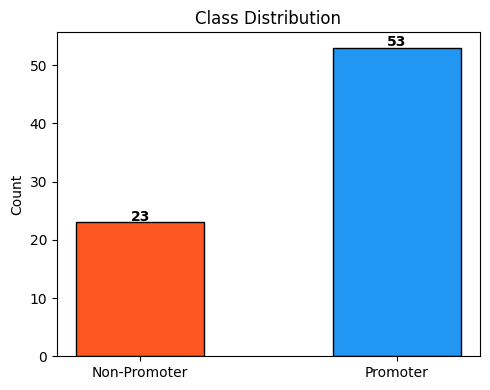

In [190]:
# --- class distribution ---
counts = df["label"].value_counts().sort_index()
print("class distribution:")
print(f"  promoters:     {counts[1]} ({round(counts[1]/len(df)*100,1)}%)")
print(f"  non-promoters: {counts[0]} ({round(counts[0]/len(df)*100,1)}%)")
print(f"  ratio: {round(counts[1]/counts[0], 2)}")

fig, ax = plt.subplots(figsize=(5, 4))
names = [label_name[i] for i in counts.index]
ax.bar(names, counts.values, color=[colors[i] for i in counts.index], edgecolor="black", width=0.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")
ax.set_title("Class Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, "3.1_class_distribution.png"), dpi=150)
plt.show()


GC content per class:
  Promoter: mean=42.14%  std=8.32%  min=26.32%  max=64.91%
  Non-Promoter: mean=50.95%  std=5.97%  min=40.35%  max=59.65%


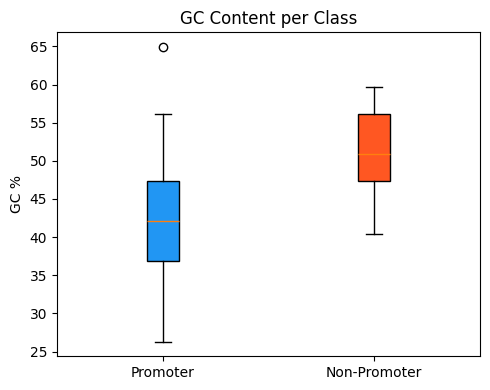

In [191]:
# --- gc content per class ---
# promoter regions are usually AT-rich (lower GC) - worth checking
df["gc_pct"] = df[SEQ_COL].apply(lambda s: (s.count("G") + s.count("C")) / len(s) * 100)

print("\nGC content per class:")
for lbl, name in label_name.items():
    v = df[df["label"] == lbl]["gc_pct"]
    print(f"  {name}: mean={v.mean():.2f}%  std={v.std():.2f}%  "
          f"min={v.min():.2f}%  max={v.max():.2f}%")

fig, ax = plt.subplots(figsize=(5, 4))
data = [df[df["label"] == lbl]["gc_pct"].values for lbl in [1, 0]]
bp = ax.boxplot(data, labels=["Promoter", "Non-Promoter"], patch_artist=True)
for patch, lbl in zip(bp["boxes"], [1, 0]):
    patch.set_facecolor(colors[lbl])
ax.set_title("GC Content per Class")
ax.set_ylabel("GC %")
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, "3.2_gc_content.png"), dpi=150)
plt.show()


nucleotide frequency per class (%):
  Promoter: A=27.7%  C=22.1%  G=20.0%  T=30.2%
  Non-Promoter: A=23.5%  C=25.2%  G=25.8%  T=25.6%


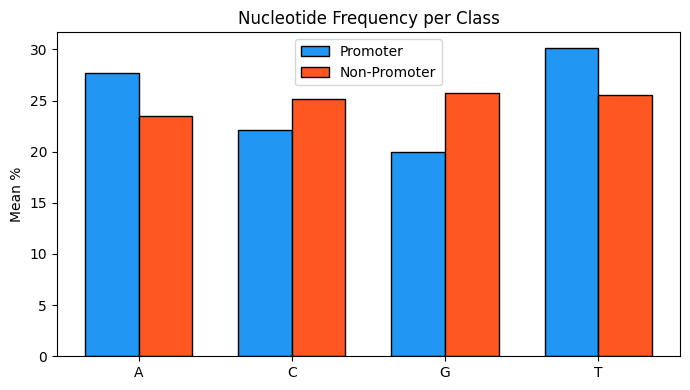

In [192]:
# --- nucleotide frequencies ---
nucs = list("ACGT")

print("\nnucleotide frequency per class (%):")
nuc_data = {}
for lbl, name in label_name.items():
    seqs = df[df["label"] == lbl][SEQ_COL]
    freqs = {n: seqs.apply(lambda s: s.count(n)/len(s)*100).mean() for n in nucs}
    nuc_data[name] = freqs
    print(f"  {name}: " + "  ".join(f"{n}={v:.1f}%" for n, v in freqs.items()))

x = np.arange(len(nucs))
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
for i, (name, clr) in enumerate(zip(["Promoter", "Non-Promoter"], ["#2196F3", "#FF5722"])):
    vals = [nuc_data[name][n] for n in nucs]
    ax.bar(x + i*w, vals, w, label=name, color=clr, edgecolor="black")
ax.set_xticks(x + w/2)
ax.set_xticklabels(nucs)
ax.set_title("Nucleotide Frequency per Class")
ax.set_ylabel("Mean %")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, "3.3_nucleotide_freq.png"), dpi=150)
plt.show()

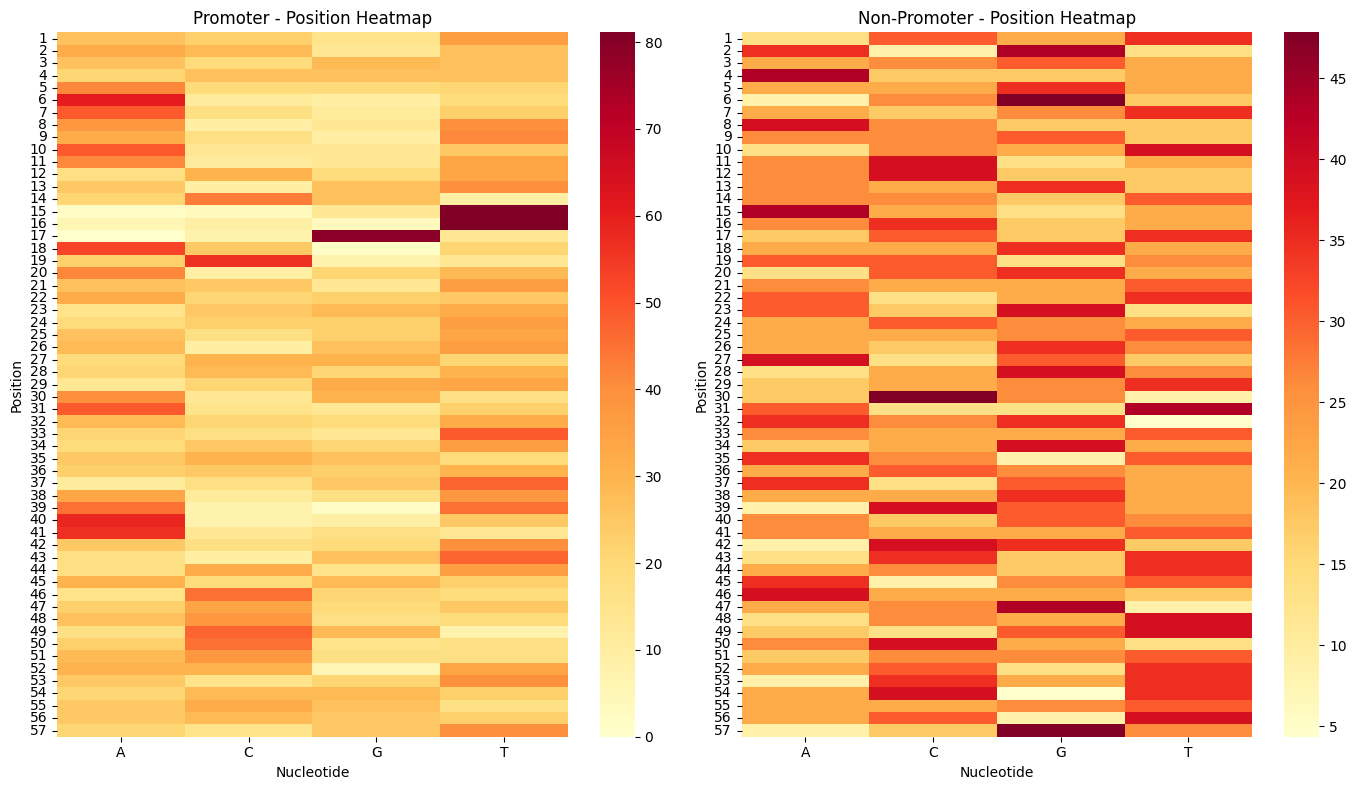

In [193]:
# --- position-wise heatmap ---
# shows which positions are conserved across promoters
# key promoter boxes show up as bright spots around positions ~10 and ~35

def pos_freq_matrix(seqs):
    mat = np.zeros((DATASET["sequence_len"], 4))
    nuc_idx = {"A": 0, "C": 1, "G": 2, "T": 3}
    for seq in seqs:
        for i, base in enumerate(seq):
            if base in nuc_idx:
                mat[i, nuc_idx[base]] += 1
    return mat / len(seqs) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, (lbl, name) in zip(axes, label_name.items()):
    seqs = df[df["label"] == lbl][SEQ_COL].tolist()
    mat = pos_freq_matrix(seqs)
    sns.heatmap(mat, ax=ax, cmap="YlOrRd",
                xticklabels=["A","C","G","T"],
                yticklabels=range(1, DATASET["sequence_len"]+1))
    ax.set_title(f"{name} - Position Heatmap")
    ax.set_xlabel("Nucleotide")
    ax.set_ylabel("Position")
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, "3.4_position_heatmap.png"), dpi=150)
plt.show()


top 5 conserved positions in promoters: [15, 16, 17, 6, 40]

top 10 2-mers in promoters:
  TT=5.60  AA=5.26  TA=4.51  AT=4.49  TG=3.72  CT=3.42  AC=3.36  GT=3.32  GC=3.26  CA=3.13
top 10 2-mers in non-promoters:
  GA=4.52  TG=4.13  TT=4.00  AG=4.00  CT=3.96  GC=3.96  CG=3.91  AC=3.74  TC=3.70  CA=3.65


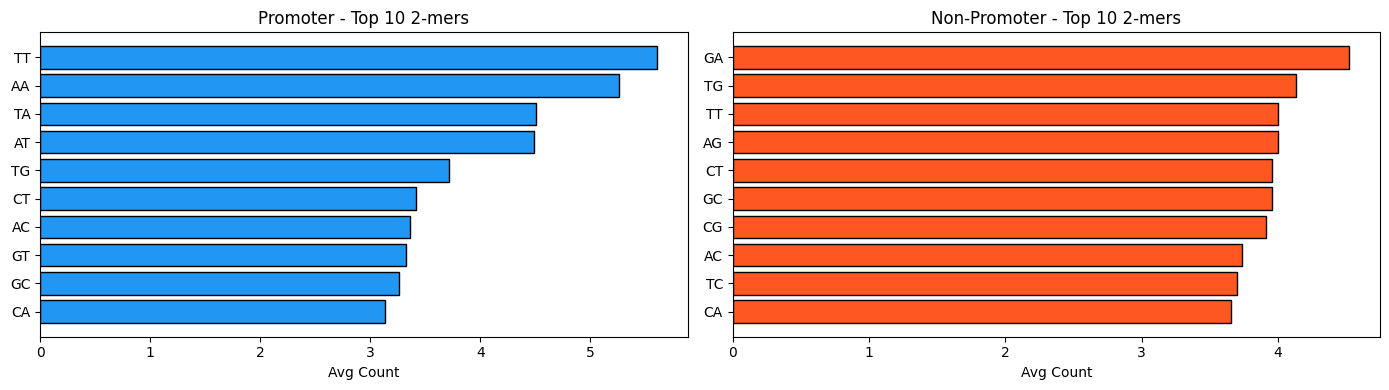

In [194]:
# top conserved positions in promoters
promo_mat = pos_freq_matrix(df[df["label"]==1][SEQ_COL].tolist())
top_positions = np.argsort(promo_mat.max(axis=1))[::-1][:5] + 1
print(f"\ntop 5 conserved positions in promoters: {top_positions.tolist()}")

# --- 2-mer frequency ---
def avg_kmer_counts(sequences, k):
    total = {}
    for seq in sequences:
        for i in range(len(seq) - k + 1):
            km = seq[i:i+k]
            total[km] = total.get(km, 0) + 1
    n = len(sequences)
    return dict(sorted({km: v/n for km, v in total.items()}.items(), key=lambda x: -x[1]))

kmer2_p  = avg_kmer_counts(df[df["label"]==1][SEQ_COL].tolist(), 2)
kmer2_np = avg_kmer_counts(df[df["label"]==0][SEQ_COL].tolist(), 2)

top10_p  = list(kmer2_p.items())[:10]
top10_np = list(kmer2_np.items())[:10]

print("\ntop 10 2-mers in promoters:")
print("  " + "  ".join(f"{k}={v:.2f}" for k, v in top10_p))
print("top 10 2-mers in non-promoters:")
print("  " + "  ".join(f"{k}={v:.2f}" for k, v in top10_np))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, top10, name, clr in zip(axes, [top10_p, top10_np],
                                 ["Promoter", "Non-Promoter"],
                                 ["#2196F3", "#FF5722"]):
    kmers, vals = zip(*top10)
    ax.barh(kmers, vals, color=clr, edgecolor="black")
    ax.set_title(f"{name} - Top 10 2-mers")
    ax.set_xlabel("Avg Count")
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, "3.5_2mer_frequency.png"), dpi=150)
plt.show()


top 10 3-mers enriched in promoters:
  AAA: +1.920
  TTT: +1.125
  ATA: +1.011
  TAT: +0.937
  TAA: +0.842
  AAT: +0.831
  TTA: +0.806
  CCC: +0.511
  ATT: +0.363
  GTT: +0.312


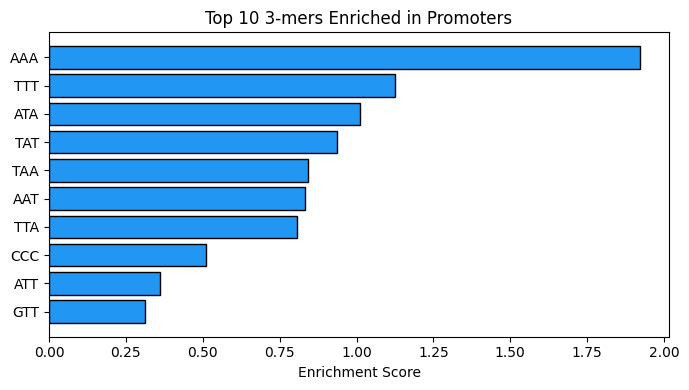


all EDA charts saved to /content/drive/MyDrive/ecoli_dna_project/outputs/eda


In [196]:
# --- 3-mer enrichment ---
# TATAAT and TTGACA are the two main e.coli promoter motifs
# looking for their constituent 3-mers here

kmer3_p  = avg_kmer_counts(df[df["label"]==1][SEQ_COL].tolist(), 3)
kmer3_np = avg_kmer_counts(df[df["label"]==0][SEQ_COL].tolist(), 3)

all_3mers = set(kmer3_p) | set(kmer3_np)
enrichment = {km: kmer3_p.get(km, 0) - kmer3_np.get(km, 0) for km in all_3mers}
top_enriched = sorted(enrichment.items(), key=lambda x: -x[1])[:10]

print("\ntop 10 3-mers enriched in promoters:")
for km, diff in top_enriched:
    print(f"  {km}: +{diff:.3f}")

kmers, diffs = zip(*top_enriched)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(kmers, diffs, color="#2196F3", edgecolor="black")
ax.set_title("Top 10 3-mers Enriched in Promoters")
ax.set_xlabel("Enrichment Score")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, "3.6_3mer_enrichment.png"), dpi=150)
plt.show()

print("\nall EDA charts saved to", eda_dir)


# step-4
### features

In [200]:
import joblib # In ML, we use it to save our trained Model and Scaler as files (.pkl).

from itertools import product # We use it to generate the exhaustive list of all DNA k-mers. ex:  product("ACGT", repeat=2) instantly creates AA, AC, AG, AT... TT.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [202]:
df = df_imbalanced.copy()

In [203]:
# build k-mer features - counts how often each substring of length k appears
def compute_kmer_features(sequence, k):
    all_kmers = ["".join(p) for p in product("ACGT", repeat=k)]
    counts = {km: 0 for km in all_kmers}
    for i in range(len(sequence) - k + 1):
        km = sequence[i:i+k]
        if km in counts:
            counts[km] += 1
    return {f"{k}mer_{km}": v for km, v in counts.items()}

def build_kmer_df(sequences, k):
    rows = [compute_kmer_features(seq, k) for seq in sequences]
    return pd.DataFrame(rows)

def biological_features(sequence):
    n = len(sequence)
    a = sequence.count("A") / n * 100
    c = sequence.count("C") / n * 100
    g = sequence.count("G") / n * 100
    t = sequence.count("T") / n * 100
    return {"gc_pct": g+c, "at_pct": a+t,
            "freq_A": a, "freq_C": c, "freq_G": g, "freq_T": t}

seqs = df[SEQ_COL].tolist()


In [204]:
seqs

['TACTAGCAATACGCTTGCGTTCGGTGGTTAAGTATGTATAATGCGCGGGCTTGTCGT',
 'TGCTATCCTGACAGTTGTCACGCTGATTGGTGTCGTTACAATCTAACGCATCGCCAA',
 'GTACTAGAGAACTAGTGCATTAGCTTATTTTTTTGTTATCATGCTAACCACCCGGCG',
 'AATTGTGATGTGTATCGAAGTGTGTTGCGGAGTAGATGTTAGAATACTAACAAACTC',
 'TCGATAATTAACTATTGACGAAAAGCTGAAAACCACTAGAATGCGCCTCCGTGGTAG',
 'AGGGGCAAGGAGGATGGAAAGAGGTTGCCGTATAAAGAAACTAGAGTCCGTTTAGGT',
 'CAGGGGGTGGAGGATTTAAGCCATCTCCTGATGACGCATAGTCAGCCCATCATGAAT',
 'TTTCTACAAAACACTTGATACTGTATGAGCATACAGTATAATTGCTTCAACAGAACA',
 'CGACTTAATATACTGCGACAGGACGTCCGTTCTGTGTAAATCGCAATGAAATGGTTT',
 'TTTTAAATTTCCTCTTGTCAGGCCGGAATAACTCCCTATAATGCGCCACCACTGACA',
 'GCAAAAATAAATGCTTGACTCTGTAGCGGGAAGGCGTATTATGCACACCCCGCGCCG',
 'CCTGAAATTCAGGGTTGACTCTGAAAGAGGAAAGCGTAATATACGCCACCTCGCGAC',
 'GATCAAAAAAATACTTGTGCAAAAAATTGGGATCCCTATAATGCGCCTCCGTTGAGA',
 'CTGCAATTTTTCTATTGCGGCCTGCGGAGAACTCCCTATAATGCGCCTCCATCGACA',
 'TTTATATTTTTCGCTTGTCAGGCCGGAATAACTCCCTATAATGCGCCACCACTGACA',
 'AAGCAAAGAAATGCTTGACTCTGTAGCGGGAAGGCGTATTATGCACACCGCCGCGCC',
 'ATGCAT

In [230]:
# build k-mer features for each k in config
kmer_parts = []
for k in FEATURES["kmer_sizes"]:
    part = build_kmer_df(seqs, k)
    kmer_parts.append(part)
    print(f"{k}-mer: {part.shape[1]} features")

df_kmer = pd.concat(kmer_parts, axis=1)

df_bio = pd.DataFrame([biological_features(s) for s in seqs])
print(f"bio features: {df_bio.shape[1]}")

2-mer: 16 features
3-mer: 64 features
bio features: 6


In [231]:
# combine everything
X = pd.concat([df_kmer, df_bio], axis=1)
y = df["label"].values

print(f"\nfinal feature matrix: {X.shape}")
print(f"{df_kmer.shape[1]} k-mer features + {df_bio.shape[1]} bio features = {X.shape[1]} total")


final feature matrix: (76, 86)
80 k-mer features + 6 bio features = 86 total


In [232]:
X

,2mer_AA,2mer_AC,2mer_AG,2mer_AT,2mer_CA,2mer_CC,2mer_CG,2mer_CT,2mer_GA,2mer_GC,...,3mer_TTA,3mer_TTC,3mer_TTG,3mer_TTT,gc_pct,at_pct,freq_A,freq_C,freq_G,freq_T
0,3,2,2,4,1,0,6,3,0,6,...,1,1,2,0,47.368421,52.631579,19.298246,17.543860,29.824561,33.333333
1,3,4,1,4,5,2,4,4,2,4,...,1,0,2,0,47.368421,52.631579,22.807018,26.315789,21.052632,29.824561
2,2,4,4,4,3,3,2,4,2,4,...,3,0,1,5,40.350877,59.649123,24.561404,21.052632,19.298246,35.087719
3,6,3,4,5,1,0,2,2,5,1,...,1,0,2,0,36.842105,63.157895,31.578947,10.526316,26.315789,31.578947
4,9,4,3,4,1,3,4,4,5,3,...,1,0,1,0,42.105263,57.894737,35.087719,21.052632,21.052632,22.807018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,2,1,1,4,2,1,4,4,2,5,...,1,2,3,6,42.105263,57.894737,14.035088,19.298246,22.807018,43.859649
72,3,2,9,3,2,1,1,4,8,2,...,0,0,0,0,49.122807,50.877193,29.824561,14.035088,35.087719,21.052632
73,5,5,2,6,6,1,3,2,5,0,...,1,3,1,0,40.350877,59.649123,31.578947,21.052632,19.298246,28.070175
74,3,5,2,4,3,2,4,5,4,1,...,2,1,1,1,43.859649,56.140351,24.561404,24.561404,19.298246,31.578947


In [233]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [234]:
# save full matrix with label
X_save = X.copy()
X_save["label"] = y
X_save.to_csv(os.path.join(PATHS["processed"], "feature_matrix.csv"), index=False)
print("feature matrix saved")

feature matrix saved


In [235]:
# stratified split - preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=SPLIT["test_size"],
    stratify=y,
    random_state=SEED
)

print(f"\ntrain set: {len(X_train)} samples")
print(f"  promoters: {(y_train==1).sum()}  non-promoters: {(y_train==0).sum()}")
print(f"test set: {len(X_test)} samples")
print(f"  promoters: {(y_test==1).sum()}  non-promoters: {(y_test==0).sum()}")


train set: 60 samples
  promoters: 42  non-promoters: 18
test set: 16 samples
  promoters: 11  non-promoters: 5


In [236]:
# fit scaler on train only - fitting on full data would leak test info into training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # only transform, never fit

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=X.columns)

joblib.dump(scaler, SCALER["save_path"])
print(f"\nscaler saved to {SCALER['save_path']}")


scaler saved to /content/drive/MyDrive/ecoli_dna_project/checkpoints/scaler.pkl


In [237]:
# save feature names - inference must use same features in same order
with open(os.path.join(PATHS["checkpoints"], "feature_names.json"), "w") as f:
    json.dump(list(X.columns), f, indent=2)

In [238]:
# save splits to drive - safe to reload after colab restart
splits = {
    "X_train": X_train_scaled,
    "X_test": X_test_scaled,
    "y_train": pd.Series(y_train, name="label"),
    "y_test": pd.Series(y_test, name="label"),
}
for name, data in splits.items():
    data.to_csv(os.path.join(PATHS["splits"], f"{name}.csv"), index=False)

In [239]:
# flag file tells later steps that splits are ready
with open(os.path.join(PATHS["splits"], "splits_ready.flag"), "w") as f:
    f.write("ready")

print("splits saved to drive")
print(f"total features: {len(X.columns)}")

splits saved to drive
total features: 86


# step-5
### setting baseline for best model finding

In [240]:
# reload splits if session restarted
try:
    X_train_scaled
except NameError:
    print("reloading splits...")
    X_train_scaled = pd.read_csv(os.path.join(PATHS["splits"], "X_train.csv"))
    X_test_scaled = pd.read_csv(os.path.join(PATHS["splits"], "X_test.csv"))
    y_train = pd.read_csv(os.path.join(PATHS["splits"], "y_train.csv")).values.ravel()
    y_test = pd.read_csv(os.path.join(PATHS["splits"], "y_test.csv")).values.ravel()

def get_metrics(model, X, y):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        "accuracy": round(accuracy_score(y, pred), 4),
        "auc": round(roc_auc_score(y, proba), 4),
        "f1": round(f1_score(y, pred, average="weighted"), 4),
    }

In [241]:
# logistic regression - class_weight handles the 70/30 imbalance
print("training logistic regression...")
lr = LogisticRegression(class_weight="balanced", random_state=SEED, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_metrics = get_metrics(lr, X_test_scaled, y_test)
print(f"  done - auc={lr_metrics['auc']}  acc={lr_metrics['accuracy']}  f1={lr_metrics['f1']}")

training logistic regression...
  done - auc=0.9818  acc=0.9375  f1=0.9389


In [242]:
# random forest - also with class_weight
print("training random forest...")
rf = RandomForestClassifier(class_weight="balanced", random_state=SEED)
rf.fit(X_train_scaled, y_train)
rf_metrics = get_metrics(rf, X_test_scaled, y_test)
print(f"  done - auc={rf_metrics['auc']}  acc={rf_metrics['accuracy']}  f1={rf_metrics['f1']}")

training random forest...
  done - auc=1.0  acc=0.9375  f1=0.9354


In [243]:
# detailed report
for name, model in [("Logistic Regression", lr), ("Random Forest", rf)]:
    print(f"\n{name}:")
    print(classification_report(y_test, model.predict(X_test_scaled),
                                 target_names=["Non-Promoter", "Promoter"]))


Logistic Regression:
              precision    recall  f1-score   support

Non-Promoter       0.83      1.00      0.91         5
    Promoter       1.00      0.91      0.95        11

    accuracy                           0.94        16
   macro avg       0.92      0.95      0.93        16
weighted avg       0.95      0.94      0.94        16


Random Forest:
              precision    recall  f1-score   support

Non-Promoter       1.00      0.80      0.89         5
    Promoter       0.92      1.00      0.96        11

    accuracy                           0.94        16
   macro avg       0.96      0.90      0.92        16
weighted avg       0.94      0.94      0.94        16



In [244]:
# results table
print("baseline results summary:")
print(f"  {'model':<25} {'accuracy':>10} {'auc':>8} {'f1':>8}")
print(f"  {'-'*53}")
for name, m in [("Logistic Regression", lr_metrics), ("Random Forest", rf_metrics)]:
    print(f"  {name:<25} {m['accuracy']:>10} {m['auc']:>8} {m['f1']:>8}")

baseline_results = pd.DataFrame([
    {"Model": "Logistic Regression", **lr_metrics},
    {"Model": "Random Forest",       **rf_metrics},
])

baseline results summary:
  model                       accuracy      auc       f1
  -----------------------------------------------------
  Logistic Regression           0.9375   0.9818   0.9389
  Random Forest                 0.9375      1.0   0.9354


In [245]:
# save models and results
baseline_dir = os.path.join(PATHS["checkpoints"], "baseline")
os.makedirs(baseline_dir, exist_ok=True)

joblib.dump(lr, os.path.join(baseline_dir, "logistic_regression.pkl"))
joblib.dump(rf, os.path.join(baseline_dir, "random_forest.pkl"))

baseline_results.to_csv(os.path.join(PATHS["evaluation"], "baseline_results.csv"), index=False)
print("\nbaseline models saved")


baseline models saved


# step-6
### AutoML Tools - lazypredict

In [247]:
from lazypredict.Supervised import LazyClassifier

In [248]:
# reload if needed
try:
    X_train_scaled
except NameError:
    X_train_scaled = pd.read_csv(os.path.join(PATHS["splits"], "X_train.csv"))
    X_test_scaled  = pd.read_csv(os.path.join(PATHS["splits"], "X_test.csv"))
    y_train = pd.read_csv(os.path.join(PATHS["splits"], "y_train.csv")).values.ravel()
    y_test  = pd.read_csv(os.path.join(PATHS["splits"], "y_test.csv")).values.ravel()

In [249]:
# lazypredict trains every sklearn classifier in one shot
clf = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None,
    random_state=AUTOML["lazypredict"]["random_state"]
)

print("running lazypredict - training 20+ models...")
print("this takes ~30-60s on colab free tier...")

lazy_results, models = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)
print(f"done - {len(lazy_results)} models evaluated")

running lazypredict - training 20+ models...
this takes ~30-60s on colab free tier...
done - 27 models evaluated


In [250]:
# sort by AUC
auc_col = "ROC AUC" if "ROC AUC" in lazy_results.columns else lazy_results.columns[1]
lazy_sorted = lazy_results.sort_values(auc_col, ascending=False)

print(f"\nleaderboard (sorted by {auc_col}):")
print(f"  {'model':<40} {auc_col:>8}  accuracy")
print(f"  {'-'*58}")
for idx, row in lazy_sorted.iterrows():
    auc = row.get(auc_col, 0)
    acc = row.get("Accuracy", 0)
    print(f"  {str(idx):<40} {auc:>8.4f}  {acc:.4f}")


leaderboard (sorted by ROC AUC):
  model                                     ROC AUC  accuracy
  ----------------------------------------------------------
  XGBClassifier                              1.0000  1.0000
  ExtraTreesClassifier                       1.0000  0.9375
  GaussianNB                                 0.9818  0.9375
  KNeighborsClassifier                       0.9818  0.9375
  LogisticRegression                         0.9818  0.9375
  NuSVC                                      0.9818  0.9375
  NearestCentroid                            0.9818  0.8125
  RandomForestClassifier                     0.9818  0.9375
  SVC                                        0.9818  0.9375
  BaggingClassifier                          0.9727  0.9375
  Perceptron                                 0.9636  0.8125
  PassiveAggressiveClassifier                0.9636  0.8125
  AdaBoostClassifier                         0.9636  0.8125
  CalibratedClassifierCV                     0.9636  0.8125
  B

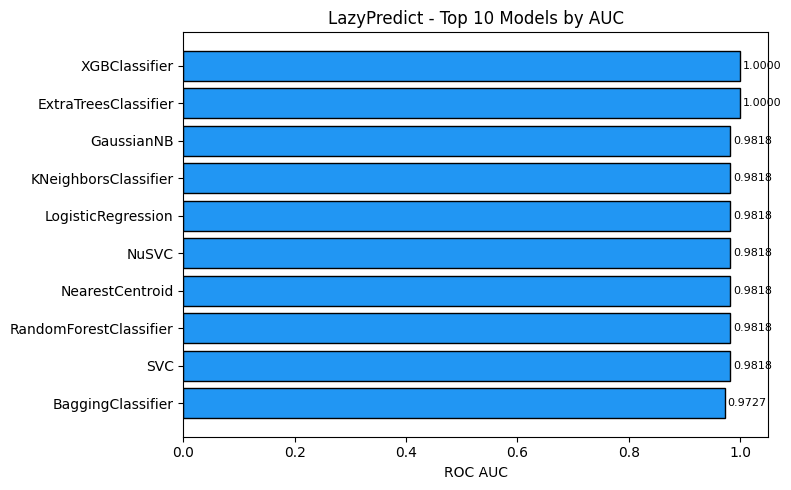

In [251]:
# plot top 10
top10 = lazy_sorted.head(10)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10.index[::-1], top10[auc_col][::-1], color="#2196F3", edgecolor="black")
ax.set_xlabel("ROC AUC")
ax.set_title("LazyPredict - Top 10 Models by AUC")
ax.set_xlim(0, 1.05)
for i, (val, name) in enumerate(zip(top10[auc_col][::-1], top10.index[::-1])):
    ax.text(val + 0.005, i, f"{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PATHS["automl"], "6.4_lazypredict_top10.png"), dpi=150)
plt.show()

In [252]:
# record top 3
top3_list = []
print("\ntop 3 models:")
for rank, (idx, row) in enumerate(lazy_sorted.head(3).iterrows(), 1):
    auc_val = round(row.get(auc_col, 0), 4)
    top3_list.append({"rank": rank, "model": idx, "auc": auc_val})
    print(f"  {rank}. {idx} - auc={auc_val}")

best_lazy_model_name = top3_list[0]["model"]
best_lazy_auc = top3_list[0]["auc"]

lazy_sorted.to_csv(os.path.join(PATHS["automl"], "lazypredict_leaderboard.csv"))
print(f"\nleaderboard saved")
print(f"best model: {best_lazy_model_name} (auc={best_lazy_auc})")


top 3 models:
  1. XGBClassifier - auc=1.0
  2. ExtraTreesClassifier - auc=1.0
  3. GaussianNB - auc=0.9818

leaderboard saved
best model: XGBClassifier (auc=1.0)


# step-7
### AutoML Tools - flaml  

In [263]:
from flaml import AutoML
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              precision_score, recall_score, classification_report)

In [264]:
# reload splits if session died
try:
    X_train_scaled
except NameError:
    X_train_scaled = pd.read_csv(os.path.join(PATHS["splits"], "X_train.csv"))
    X_test_scaled  = pd.read_csv(os.path.join(PATHS["splits"], "X_test.csv"))
    y_train = pd.read_csv(os.path.join(PATHS["splits"], "y_train.csv")).values.ravel()
    y_test  = pd.read_csv(os.path.join(PATHS["splits"], "y_test.csv")).values.ravel()

settings = {
    "task": AUTOML["flaml"]["task"],
    "time_budget": AUTOML["flaml"]["time_budget"],
    "metric": AUTOML["flaml"]["metric"],
    "seed": AUTOML["flaml"]["seed"],
    "verbose": AUTOML["flaml"]["verbose"],
}

print(f"running FLAML - {settings['time_budget']}s budget, optimizing {settings['metric']}")
print("please wait...")
automl = AutoML()
automl.fit(X_train_scaled, y_train, **settings)
print("done")

INFO:flaml.automl.task.generic_task:class 0 augmented from 18 to 36
INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


running FLAML - 120s budget, optimizing roc_auc
please wait...


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


done


In [265]:
# what did flaml find
best_model_name = automl.best_estimator
best_model_params = automl.best_config
best_val_auc = round(1 - automl.best_loss, 4)

print(f"\nbest model: {best_model_name}")
print(f"best val auc: {best_val_auc}")
print("hyperparameters:")
for param, val in best_model_params.items():
    v = round(val, 4) if isinstance(val, float) else val
    print(f"  {param}: {v}")
    # evaluate on test set
y_pred  = automl.predict(X_test_scaled)
y_proba = automl.predict_proba(X_test_scaled)[:, 1]

flaml_metrics = {
    "model": best_model_name,
    "accuracy": round(accuracy_score(y_test, y_pred), 4),
    "auc": round(roc_auc_score(y_test, y_proba), 4),
    "f1":  round(f1_score(y_test, y_pred, average="weighted"), 4),
    "precision": round(precision_score(y_test, y_pred, average="weighted", zero_division=0), 4),
    "recall": round(recall_score(y_test, y_pred, average="weighted"), 4),
}

print("\ntest set metrics:")
for k, v in flaml_metrics.items():
    if k != "model":
        print(f"  {k}: {v}")

print("\nclassification report:")
print(classification_report(y_test, y_pred, target_names=["Non-Promoter", "Promoter"]))



best model: extra_tree
best val auc: 1.0
hyperparameters:
  n_estimators: 8
  max_features: 0.128
  max_leaves: 10
  criterion: entropy

test set metrics:
  accuracy: 0.9375
  auc: 0.9818
  f1: 0.9389
  precision: 0.9479
  recall: 0.9375

classification report:
              precision    recall  f1-score   support

Non-Promoter       0.83      1.00      0.91         5
    Promoter       1.00      0.91      0.95        11

    accuracy                           0.94        16
   macro avg       0.92      0.95      0.93        16
weighted avg       0.95      0.94      0.94        16



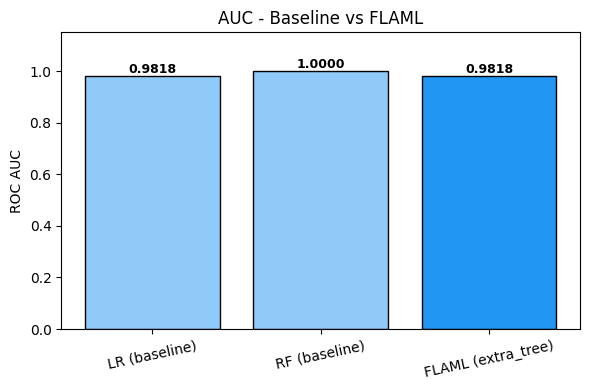

In [266]:
# quick comparison bar chart
fig, ax = plt.subplots(figsize=(6, 4))
try:
    bdf = pd.read_csv(os.path.join(PATHS["evaluation"], "baseline_results.csv"))
    lr_auc = float(bdf[bdf["Model"]=="Logistic Regression"]["auc"].values[0])
    rf_auc = float(bdf[bdf["Model"]=="Random Forest"]["auc"].values[0])
    aucs   = [lr_auc, rf_auc, flaml_metrics["auc"]]
    clrs   = ["#90CAF9", "#90CAF9", "#2196F3"]
except Exception:
    aucs = [0, 0, flaml_metrics["auc"]]
    clrs = ["#90CAF9", "#90CAF9", "#2196F3"]

labels = ["LR (baseline)", "RF (baseline)", f"FLAML ({best_model_name})"]
bars = ax.bar(labels, aucs, color=clrs, edgecolor="black")
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", fontweight="bold", fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title("AUC - Baseline vs FLAML")
ax.set_ylabel("ROC AUC")
plt.xticks(rotation=12)
plt.tight_layout()
plt.savefig(os.path.join(PATHS["automl"], "7.4_flaml_vs_baseline.png"), dpi=150)
plt.show()

In [267]:
# save model and results
joblib.dump(automl, os.path.join(PATHS["checkpoints"], "flaml_best.pkl"))

['/content/drive/MyDrive/ecoli_dna_project/checkpoints/flaml_best.pkl']

In [268]:
flaml_results = {
    "best_model":       best_model_name,
    "best_val_auc":     best_val_auc,
    "best_hyperparams": best_model_params,
    "test_metrics":     flaml_metrics,
    "time_budget":      settings["time_budget"],
}
with open(os.path.join(PATHS["automl"], "flaml_results.json"), "w") as f:
    json.dump(flaml_results, f, indent=2)

print("flaml model and results saved")

flaml model and results saved


# step-8
### Best Model comparision and selection

In [269]:
# reload everything from disk if variables lost
try:
    lr_metrics
except NameError:
    bdf = pd.read_csv(os.path.join(PATHS["evaluation"], "baseline_results.csv"))
    lr_metrics = bdf[bdf["Model"]=="Logistic Regression"].iloc[0].to_dict()
    rf_metrics = bdf[bdf["Model"]=="Random Forest"].iloc[0].to_dict()

try:
    flaml_metrics
except NameError:
    with open(os.path.join(PATHS["automl"], "flaml_results.json")) as f:
        fr = json.load(f)
    flaml_metrics   = fr["test_metrics"]
    best_model_name = fr["best_model"]

try:
    lazy_sorted
except NameError:
    lazy_sorted = pd.read_csv(os.path.join(PATHS["automl"], "lazypredict_leaderboard.csv"),
                               index_col=0)
    auc_col = "ROC AUC"
    best_lazy_model_name = lazy_sorted.index[0]
    best_lazy_auc = float(lazy_sorted.iloc[0][auc_col])

try:
    X_test_scaled
except NameError:
    X_test_scaled = pd.read_csv(os.path.join(PATHS["splits"], "X_test.csv"))
    y_test = pd.read_csv(os.path.join(PATHS["splits"], "y_test.csv")).values.ravel()

In [270]:
# collect all results in one table
lazy_auc = float(lazy_sorted.iloc[0].get("ROC AUC", lazy_sorted.iloc[0].get(auc_col, 0)))
lazy_acc = float(lazy_sorted.iloc[0].get("Accuracy", 0))
lazy_f1  = float(lazy_sorted.iloc[0].get("F1 Score", lazy_sorted.iloc[0].get("F1", 0)))

In [271]:
rows = [
    {"Approach": "Manual - Logistic Reg",  "Best Model": "LogisticRegression",
     "Test AUC": lr_metrics["auc"], "Test Accuracy": lr_metrics["accuracy"], "Test F1": lr_metrics["f1"]},
    {"Approach": "Manual - Random Forest", "Best Model": "RandomForest",
     "Test AUC": rf_metrics["auc"], "Test Accuracy": rf_metrics["accuracy"], "Test F1": rf_metrics["f1"]},
    {"Approach": "LazyPredict",            "Best Model": str(best_lazy_model_name),
     "Test AUC": round(lazy_auc,4), "Test Accuracy": round(lazy_acc,4), "Test F1": round(lazy_f1,4)},
    {"Approach": "FLAML",                  "Best Model": str(best_model_name),
     "Test AUC": flaml_metrics["auc"], "Test Accuracy": flaml_metrics["accuracy"], "Test F1": flaml_metrics["f1"]},
]

In [272]:
comparison_df = pd.DataFrame(rows)

print("master comparison table:")
print(f"  {'approach':<26} {'model':<28} {'auc':>6} {'acc':>6} {'f1':>6}")
print(f"  {'-'*74}")
for _, r in comparison_df.iterrows():
    print(f"  {r['Approach']:<26} {r['Best Model']:<28} "
          f"{r['Test AUC']:>6.4f} {r['Test Accuracy']:>6.4f} {r['Test F1']:>6.4f}")

master comparison table:
  approach                   model                           auc    acc     f1
  --------------------------------------------------------------------------
  Manual - Logistic Reg      LogisticRegression           0.9818 0.9375 0.9389
  Manual - Random Forest     RandomForest                 1.0000 0.9375 0.9354
  LazyPredict                XGBClassifier                1.0000 1.0000 1.0000
  FLAML                      extra_tree                   0.9818 0.9375 0.9389


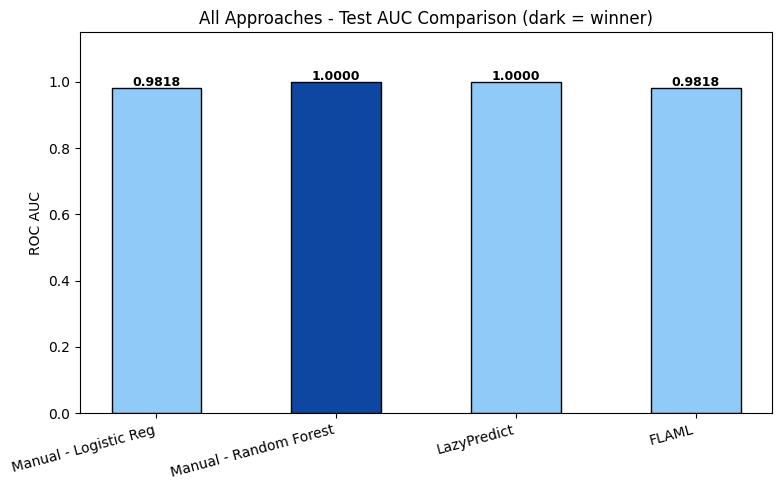

In [273]:

# auc comparison chart
aucs   = comparison_df["Test AUC"].tolist()
best_i = aucs.index(max(aucs))
clrs   = ["#90CAF9"] * len(aucs)
clrs[best_i] = "#0D47A1"

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(comparison_df["Approach"], aucs, color=clrs, edgecolor="black", width=0.5)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", fontsize=9, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.set_ylabel("ROC AUC")
ax.set_title("All Approaches - Test AUC Comparison (dark = winner)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(PATHS["evaluation"], "8.2_auc_comparison.png"), dpi=150)
plt.show()

In [275]:
# pick the winner
best_row = comparison_df.loc[comparison_df["Test AUC"].idxmax()]
BEST_APPROACH   = best_row["Approach"]
BEST_MODEL_NAME = best_row["Best Model"]
BEST_AUC        = best_row["Test AUC"]
BEST_ACC        = best_row["Test Accuracy"]
BEST_F1         = best_row["Test F1"]

print(f"\nwinner: {BEST_APPROACH}")
print(f"  model: {BEST_MODEL_NAME}")
print(f"  auc:   {BEST_AUC}")
print(f"  acc:   {BEST_ACC}")
print(f"  f1:    {BEST_F1}")

# using AUC not accuracy because dataset is imbalanced 70/30
# AUC measures ranking quality, not affected by class distribution


winner: Manual - Random Forest
  model: RandomForest
  auc:   1.0
  acc:   0.9375
  f1:    0.9354


In [276]:
# save winner model under a clear name
if "FLAML" in BEST_APPROACH:
    src = os.path.join(PATHS["checkpoints"], "flaml_best.pkl")
elif "Forest" in BEST_MODEL_NAME:
    src = os.path.join(PATHS["checkpoints"], "baseline", "random_forest.pkl")
else:
    src = os.path.join(PATHS["checkpoints"], "baseline", "logistic_regression.pkl")

best_model_obj = joblib.load(src)
joblib.dump(best_model_obj, os.path.join(PATHS["checkpoints"], "best_model.pkl"))

winner_summary = {
    "approach":   BEST_APPROACH,
    "model_name": BEST_MODEL_NAME,
    "test_auc":   BEST_AUC,
    "test_acc":   BEST_ACC,
    "test_f1":    BEST_F1,
}
with open(os.path.join(PATHS["checkpoints"], "winner_summary.json"), "w") as f:
    json.dump(winner_summary, f, indent=2)

comparison_df.to_csv(os.path.join(PATHS["evaluation"], "comparison.csv"), index=False)
print("\nwinner model and comparison table saved")



winner model and comparison table saved


# step-9
### evaluation

In [277]:
# reload if needed
try:
    best_model_obj
except NameError:
    best_model_obj = joblib.load(os.path.join(PATHS["checkpoints"], "best_model.pkl"))
    with open(os.path.join(PATHS["checkpoints"], "winner_summary.json")) as f:
        winner_summary  = json.load(f)
    BEST_MODEL_NAME = winner_summary["model_name"]
    BEST_APPROACH   = winner_summary["approach"]

try:
    X_test_scaled
except NameError:
    X_test_scaled = pd.read_csv(os.path.join(PATHS["splits"], "X_test.csv"))
    y_test = pd.read_csv(os.path.join(PATHS["splits"], "y_test.csv")).values.ravel()

y_pred  = best_model_obj.predict(X_test_scaled)
y_proba = best_model_obj.predict_proba(X_test_scaled)[:, 1]
eva     = PATHS["evaluation"]


In [278]:
# all metrics on test set
metrics = {
    "Accuracy":           round(accuracy_score(y_test, y_pred), 4),
    "AUC":                round(roc_auc_score(y_test, y_proba), 4),
    "F1 Weighted":        round(f1_score(y_test, y_pred, average="weighted"), 4),
    "F1 Macro":           round(f1_score(y_test, y_pred, average="macro"), 4),
    "Precision Weighted": round(precision_score(y_test, y_pred, average="weighted", zero_division=0), 4),
    "Recall Weighted":    round(recall_score(y_test, y_pred, average="weighted"), 4),
    "MCC":                round(matthews_corrcoef(y_test, y_pred), 4),
    # MCC is the best single metric for imbalanced binary classification
}

print(f"test set evaluation - {BEST_MODEL_NAME}")
print(f"  samples: {len(y_test)}")
for name, val in metrics.items():
    print(f"  {name}: {val}")

print("\nclassification report:")
print(classification_report(y_test, y_pred, target_names=["Non-Promoter", "Promoter"]))


test set evaluation - RandomForest
  samples: 16
  Accuracy: 0.9375
  AUC: 1.0
  F1 Weighted: 0.9354
  F1 Macro: 0.9227
  Precision Weighted: 0.9427
  Recall Weighted: 0.9375
  MCC: 0.8563

classification report:
              precision    recall  f1-score   support

Non-Promoter       1.00      0.80      0.89         5
    Promoter       0.92      1.00      0.96        11

    accuracy                           0.94        16
   macro avg       0.96      0.90      0.92        16
weighted avg       0.94      0.94      0.94        16



confusion matrix: TP=11  TN=4  FP=1  FN=0


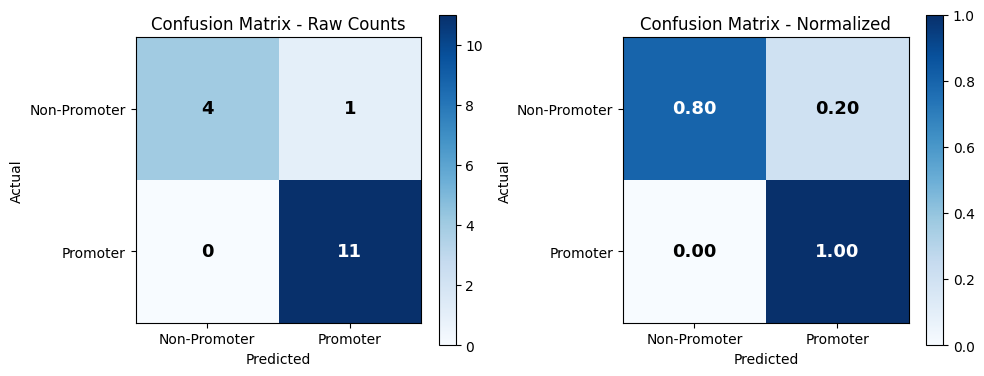

In [279]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
tn, fp, fn, tp = cm.ravel()
print(f"confusion matrix: TP={tp}  TN={tn}  FP={fp}  FN={fn}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title in zip(axes, [cm, cm_norm], ["Raw Counts", "Normalized"]):
    im = ax.imshow(data, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Non-Promoter","Promoter"])
    ax.set_yticklabels(["Non-Promoter","Promoter"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {title}")
    for i in range(2):
        for j in range(2):
            val = f"{data[i,j]:.2f}" if title == "Normalized" else str(data[i,j])
            ax.text(j, i, val, ha="center", va="center", fontsize=13,
                    fontweight="bold",
                    color="white" if data[i,j] > data.max()/2 else "black")
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(eva, "9.2_confusion_matrix.png"), dpi=150)
plt.show()

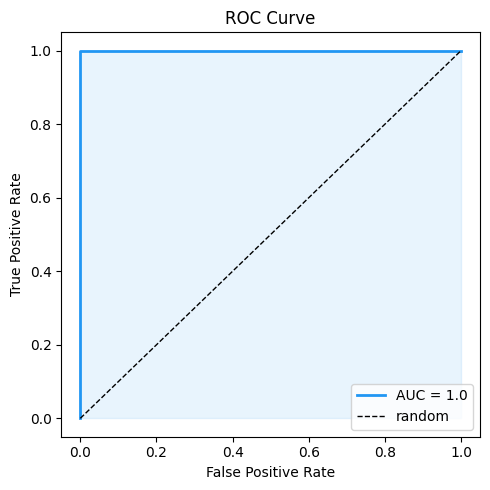

AUC = 1.0


In [280]:
# roc curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="#2196F3", lw=2, label=f"AUC = {metrics['AUC']}")
ax.plot([0,1], [0,1], "k--", lw=1, label="random")
ax.fill_between(fpr, tpr, alpha=0.1, color="#2196F3")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve"); ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(eva, "9.3_roc_curve.png"), dpi=150)
plt.show()
print(f"AUC = {metrics['AUC']}")

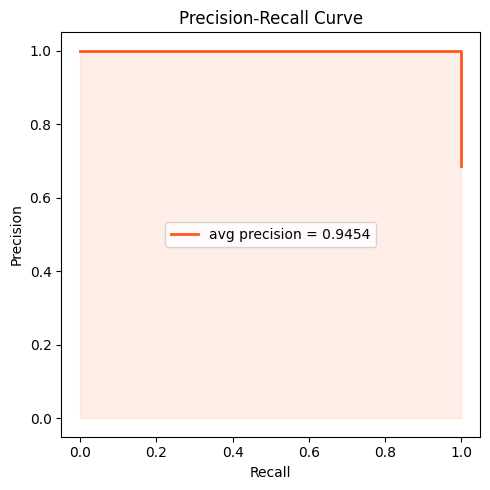

average precision = 0.9454


In [281]:
# precision recall curve
prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_proba)
avg_prec = round(float(np.mean(prec_vals)), 4)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(rec_vals, prec_vals, color="#FF5722", lw=2, label=f"avg precision = {avg_prec}")
ax.fill_between(rec_vals, prec_vals, alpha=0.1, color="#FF5722")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(eva, "9.4_pr_curve.png"), dpi=150)
plt.show()
print(f"average precision = {avg_prec}")



optimal threshold: 0.65 (default is 0.5)
f1 at optimal:     1.0


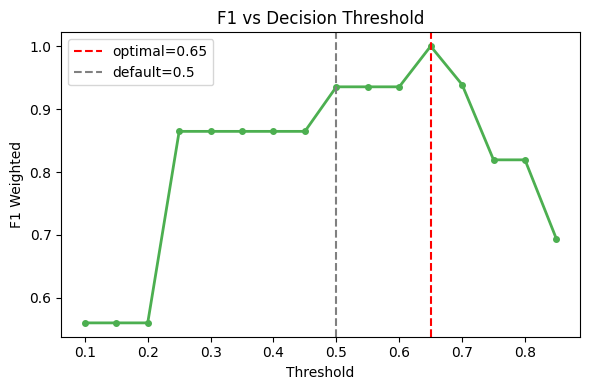

In [282]:
# optimal threshold - 0.5 isn't always best for imbalanced data
thresholds = np.arange(0.1, 0.9, 0.05)
f1s = [f1_score(y_test, (y_proba >= t).astype(int), average="weighted", zero_division=0)
       for t in thresholds]
optimal_thresh = thresholds[np.argmax(f1s)]
print(f"\noptimal threshold: {optimal_thresh:.2f} (default is 0.5)")
print(f"f1 at optimal:     {round(max(f1s), 4)}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thresholds, f1s, color="#4CAF50", lw=2, marker="o", markersize=4)
ax.axvline(x=optimal_thresh, color="red", linestyle="--", label=f"optimal={optimal_thresh:.2f}")
ax.axvline(x=0.5, color="gray", linestyle="--", label="default=0.5")
ax.set_xlabel("Threshold"); ax.set_ylabel("F1 Weighted")
ax.set_title("F1 vs Decision Threshold"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(eva, "9.5_threshold_curve.png"), dpi=150)
plt.show()

with open(os.path.join(PATHS["checkpoints"], "threshold.json"), "w") as f:
    json.dump({"optimal_threshold": float(optimal_thresh)}, f)



5-fold cross validation:
  (scaler refit per fold - no leakage)
  fold       auc      f1     acc
  ------------------------------
  fold 1   0.9273  0.9354  0.9375
  fold 2   0.7955  0.7901  0.8000
  fold 3   1.0000  1.0000  1.0000
  fold 4   0.8000  0.7121  0.7333
  fold 5   0.8700  0.7702  0.8000
    mean   0.8786  0.8416
     std   0.0778  0.1081

  mean AUC = 0.8786 +/- 0.0778  <- report this in interviews


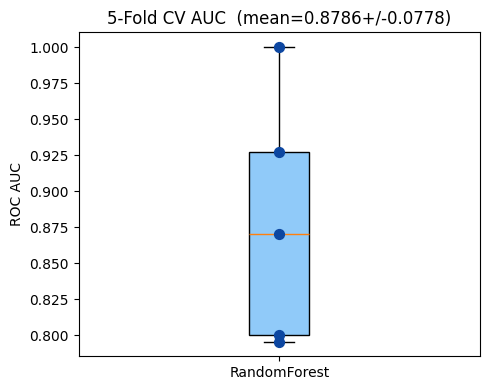

In [283]:
# 5-fold CV - proves model isn't just lucky on one split
# scaler refit inside each fold to avoid leakage
print("\n5-fold cross validation:")
print("  (scaler refit per fold - no leakage)")

X_full = pd.read_csv(os.path.join(PATHS["processed"], "feature_matrix.csv"))
y_full = X_full.pop("label").values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_aucs, fold_f1s, fold_accs = [], [], []

print(f"  {'fold':<6} {'auc':>7} {'f1':>7} {'acc':>7}")
print(f"  {'-'*30}")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_full, y_full), 1):
    X_tr, X_val = X_full.iloc[tr_idx], X_full.iloc[val_idx]
    y_tr, y_val = y_full[tr_idx], y_full[val_idx]

    sc = StandardScaler()
    X_tr_s  = sc.fit_transform(X_tr)
    X_val_s = sc.transform(X_val)

    m = RandomForestClassifier(random_state=SEED, class_weight="balanced")
    m.fit(X_tr_s, y_tr)

    auc = round(roc_auc_score(y_val, m.predict_proba(X_val_s)[:,1]), 4)
    f1  = round(f1_score(y_val, m.predict(X_val_s), average="weighted"), 4)
    acc = round(accuracy_score(y_val, m.predict(X_val_s)), 4)
    fold_aucs.append(auc); fold_f1s.append(f1); fold_accs.append(acc)
    print(f"  fold {fold}  {auc:>7.4f} {f1:>7.4f} {acc:>7.4f}")

mean_auc = round(np.mean(fold_aucs), 4)
std_auc  = round(np.std(fold_aucs), 4)
mean_f1  = round(np.mean(fold_f1s), 4)
std_f1   = round(np.std(fold_f1s), 4)
print(f"  {'mean':>6}  {mean_auc:>7.4f} {mean_f1:>7.4f}")
print(f"  {'std':>6}  {std_auc:>7.4f} {std_f1:>7.4f}")
print(f"\n  mean AUC = {mean_auc} +/- {std_auc}  <- report this in interviews")

fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot(fold_aucs, patch_artist=True, boxprops=dict(facecolor="#90CAF9"))
ax.scatter([1]*5, fold_aucs, color="#0D47A1", zorder=5, s=50)
ax.set_xticks([1]); ax.set_xticklabels(["RandomForest"])
ax.set_ylabel("ROC AUC")
ax.set_title(f"5-Fold CV AUC  (mean={mean_auc}+/-{std_auc})")
plt.tight_layout()
plt.savefig(os.path.join(eva, "9.6_kfold_auc.png"), dpi=150)
plt.show()


In [284]:
# save everything
eval_summary = {
    "model": BEST_MODEL_NAME, "approach": BEST_APPROACH,
    "test_metrics": metrics,
    "optimal_threshold": float(optimal_thresh),
    "kfold": {"mean_auc": mean_auc, "std_auc": std_auc,
               "mean_f1": mean_f1, "std_f1": std_f1,
               "fold_aucs": fold_aucs},
}
with open(os.path.join(eva, "evaluation_summary.json"), "w") as f:
    json.dump(eval_summary, f, indent=2)

pd.DataFrame({"fold": range(1,6), "auc": fold_aucs,
              "f1": fold_f1s, "acc": fold_accs}).to_csv(
    os.path.join(eva, "kfold_results.csv"), index=False)

print("\nall evaluation results saved")



all evaluation results saved


# step-10
### SHAP Explainability

In [285]:
shap.initjs()

shap_dir = PATHS["shap"]

In [286]:
# reload if needed
try:
    best_model_obj
except NameError:
    best_model_obj = joblib.load(os.path.join(PATHS["checkpoints"], "best_model.pkl"))

try:
    X_test_scaled
except NameError:
    X_test_scaled = pd.read_csv(os.path.join(PATHS["splits"], "X_test.csv"))
    y_test = pd.read_csv(os.path.join(PATHS["splits"], "y_test.csv")).values.ravel()

with open(os.path.join(PATHS["checkpoints"], "feature_names.json")) as f:
    feature_names = json.load(f)


In [287]:
# use max 50 samples to avoid running out of RAM on colab
X_shap = X_test_scaled.iloc[:50]
print(f"computing SHAP on {len(X_shap)} samples")

computing SHAP on 16 samples


In [288]:
# pick explainer based on model type
# TreeExplainer is much faster for tree-based models
tree_types = ["RandomForestClassifier", "ExtraTreesClassifier",
              "GradientBoostingClassifier", "XGBClassifier", "LGBMClassifier"]

model_type = type(best_model_obj).__name__
if model_type in tree_types:
    explainer = shap.TreeExplainer(best_model_obj)
    explainer_type = "TreeExplainer"
    print(f"using TreeExplainer for {model_type}")
else:
    X_train_scaled = pd.read_csv(os.path.join(PATHS["splits"], "X_train.csv"))
    bg = shap.kmeans(X_train_scaled, 10)
    explainer = shap.KernelExplainer(best_model_obj.predict_proba, bg)
    explainer_type = "KernelExplainer"
    print(f"using KernelExplainer for {model_type}")


using TreeExplainer for RandomForestClassifier


In [289]:
# compute shap values
shap_raw = explainer.shap_values(X_shap)

# handle different output formats - we want class 1 (promoter)
if isinstance(shap_raw, list):
    shap_vals = shap_raw[1]
elif shap_raw.ndim == 3:
    shap_vals = shap_raw[:, :, 1]
else:
    shap_vals = shap_raw

print(f"shap values shape: {shap_vals.shape}")

shap values shape: (16, 86)


In [290]:
# global importance - mean absolute shap per feature
mean_abs = np.abs(shap_vals).mean(axis=0)
shap_df = pd.DataFrame({
    "feature":    feature_names,
    "shap_value": mean_abs
}).sort_values("shap_value", ascending=False).reset_index(drop=True)

print("\ntop 10 features by mean |SHAP|:")
print(f"  {'rank':<5} {'feature':<25} {'mean |shap|':>12}")
print(f"  {'-'*44}")
for i, row in shap_df.head(10).iterrows():
    print(f"  {i+1:<5} {row['feature']:<25} {row['shap_value']:>12.4f}")


top 10 features by mean |SHAP|:
  rank  feature                    mean |shap|
  --------------------------------------------
  1     3mer_AAA                        0.0399
  2     3mer_AGC                        0.0385
  3     3mer_ATA                        0.0281
  4     3mer_TCA                        0.0280
  5     2mer_AT                         0.0262
  6     2mer_TA                         0.0248
  7     freq_G                          0.0244
  8     3mer_TTA                        0.0219
  9     2mer_AA                         0.0211
  10    at_pct                          0.0184


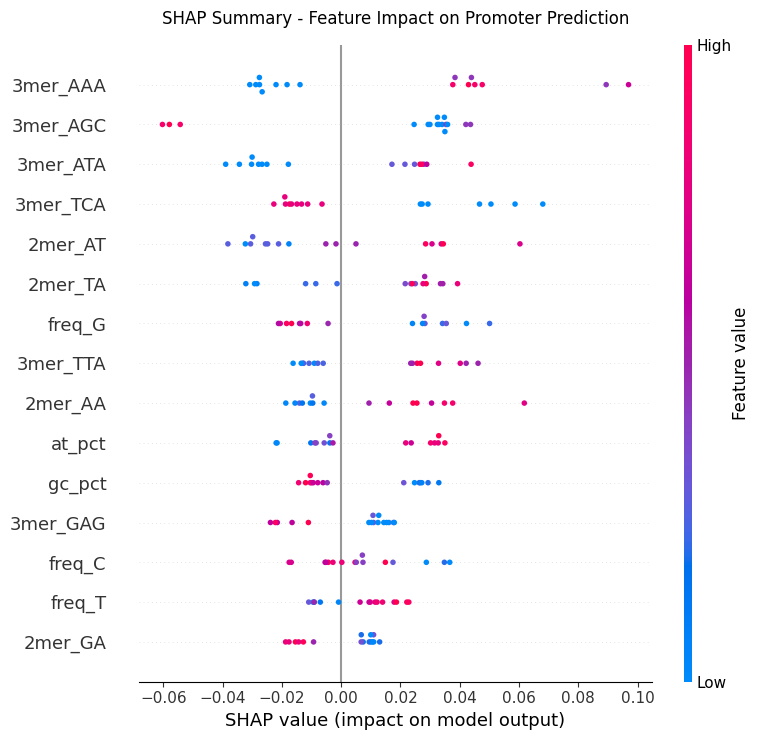

In [291]:
# summary plot - shows direction and magnitude for each feature
plt.figure(figsize=(8, 8))
shap.summary_plot(shap_vals, X_shap, feature_names=feature_names,
                  show=False, max_display=15)
plt.title("SHAP Summary - Feature Impact on Promoter Prediction", pad=15)
plt.tight_layout()
plt.savefig(os.path.join(shap_dir, "10.3_shap_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

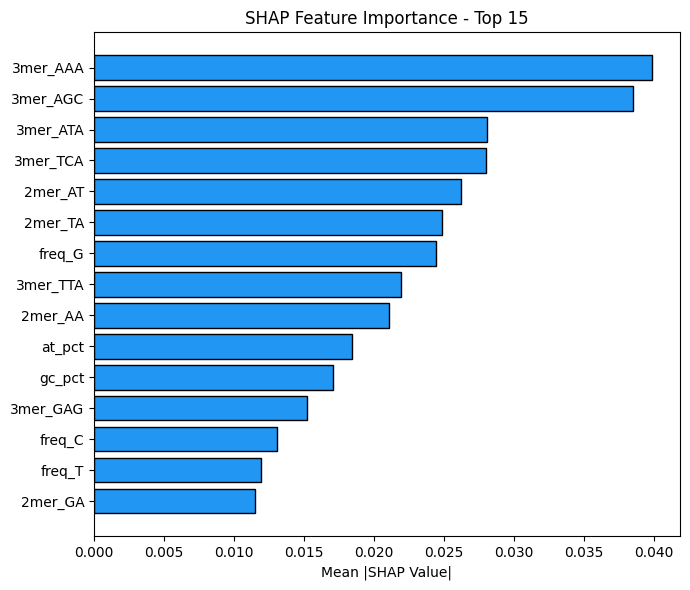

In [292]:
# bar plot - simpler view of global importance
top15 = shap_df.head(15)
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top15["feature"][::-1], top15["shap_value"][::-1],
        color="#2196F3", edgecolor="black")
ax.set_xlabel("Mean |SHAP Value|")
ax.set_title("SHAP Feature Importance - Top 15")
plt.tight_layout()
plt.savefig(os.path.join(shap_dir, "10.4_shap_bar.png"), dpi=150)
plt.show()


force plot - sample 1 (true label: Promoter)
  3mer_AAA: shap=+0.0377  (toward Promoter)
  3mer_AGC: shap=+0.0354  (toward Promoter)
  2mer_AT: shap=+0.0345  (toward Promoter)


<Figure size 1400x300 with 0 Axes>

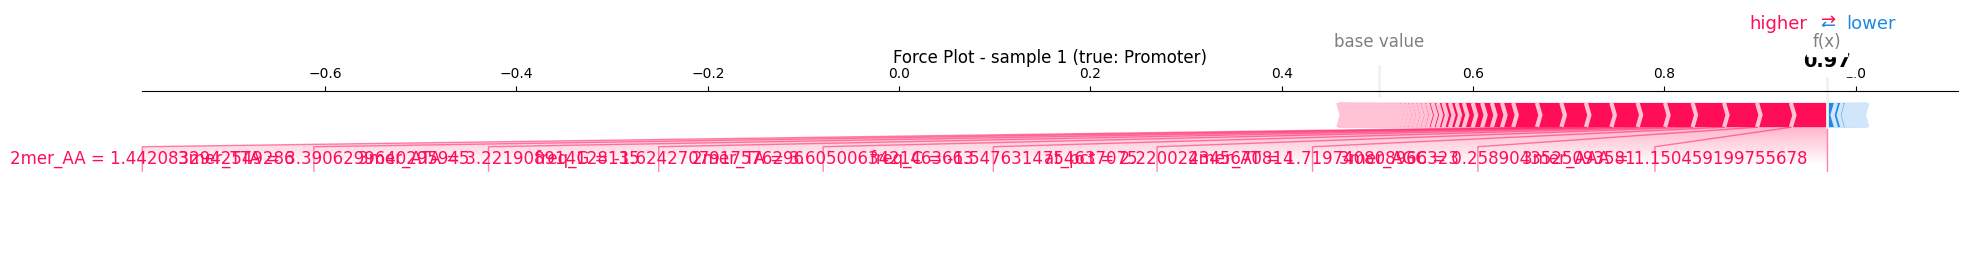


force plot - sample 2 (true label: Promoter)
  3mer_AAA: shap=+0.0451  (toward Promoter)
  3mer_ATA: shap=-0.0390  (away from Promoter)
  freq_G: shap=+0.0355  (toward Promoter)


<Figure size 1400x300 with 0 Axes>

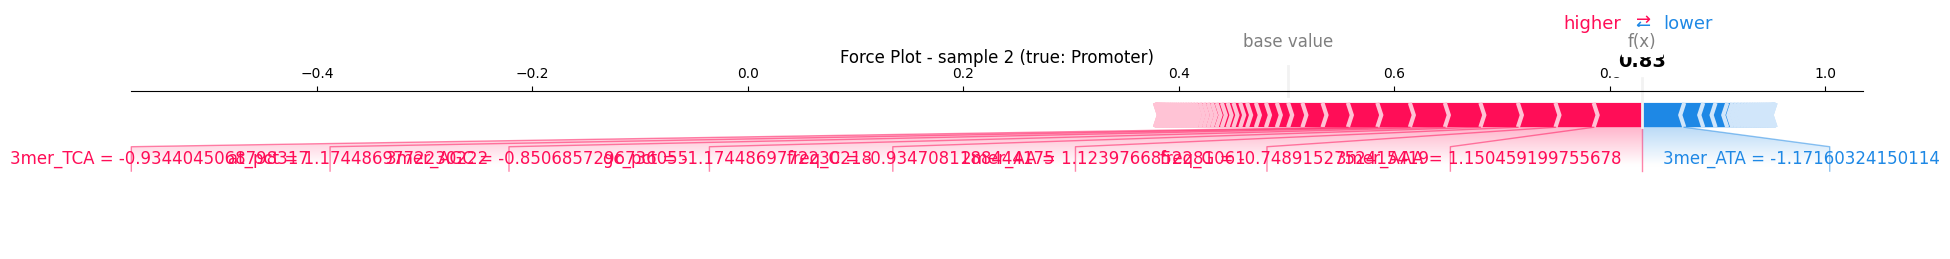

In [293]:
# force plots for 2 individual samples
expected_val = explainer.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    expected_val = expected_val[1]

for i in [0, 1]:
    lbl = "Promoter" if y_test[i] == 1 else "Non-Promoter"
    print(f"\nforce plot - sample {i+1} (true label: {lbl})")

    # top 3 drivers for this specific prediction
    top3 = np.argsort(np.abs(shap_vals[i]))[::-1][:3]
    for idx in top3:
        direction = "toward Promoter" if shap_vals[i][idx] > 0 else "away from Promoter"
        print(f"  {feature_names[idx]}: shap={shap_vals[i][idx]:+.4f}  ({direction})")

    fig = plt.figure(figsize=(14, 3))
    shap.force_plot(expected_val, shap_vals[i], X_shap.iloc[i],
                    feature_names=feature_names, matplotlib=True, show=False)
    plt.title(f"Force Plot - sample {i+1} (true: {lbl})", pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(shap_dir, f"10.5_force_plot_sample{i+1}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

In [294]:
# biological interpretation of top 5 features
# TATAAT = -10 box (Pribnow box) - most conserved promoter element
# TTGACA = -35 box - upstream recognition element
print("\nbiological interpretation of top 5 features:")
tataat = {"TAT","ATA","TAA","AAT"}
ttgaca = {"TTG","TGA","GAC","ACA"}

for rank, row in shap_df.head(5).iterrows():
    feat = row["feature"]
    val = row["shap_value"]
    km = feat.split("_")[-1] if "_" in feat else feat

    if km in tataat:
        note = "part of TATAAT -10 box motif"
    elif km in ttgaca:
        note = "part of TTGACA -35 box motif"
    elif "gc" in feat:
        note = "GC% - promoters tend to be AT-rich"
    elif "at" in feat:
        note = "AT% - TATAAT is AT-rich, strong promoter signal"
    elif "freq_" in feat:
        note = "nucleotide composition signal"
    else:
        note = "sequence pattern signal"

    print(f"  {rank+1}. {feat} ({val:.4f}) - {note}")



biological interpretation of top 5 features:
  1. 3mer_AAA (0.0399) - sequence pattern signal
  2. 3mer_AGC (0.0385) - sequence pattern signal
  3. 3mer_ATA (0.0281) - part of TATAAT -10 box motif
  4. 3mer_TCA (0.0280) - sequence pattern signal
  5. 2mer_AT (0.0262) - sequence pattern signal


In [295]:
# save outputs
shap_df.to_csv(os.path.join(shap_dir, "shap_feature_importance.csv"), index=False)
with open(os.path.join(shap_dir, "shap_summary.json"), "w") as f:
    json.dump({
        "explainer": explainer_type,
        "samples": len(X_shap),
        "top5": shap_df.head(5)[["feature","shap_value"]].to_dict("records"),
    }, f, indent=2)

print("\nshap outputs saved to", shap_dir)


shap outputs saved to /content/drive/MyDrive/ecoli_dna_project/outputs/evaluation/shap


# step-11
### save best model (versioned)

In [296]:
# reload if needed
try:
    best_model_obj
except NameError:
    best_model_obj = joblib.load(os.path.join(PATHS["checkpoints"], "best_model.pkl"))

try:
    scaler
except NameError:
    scaler = joblib.load(SCALER["save_path"])

try:
    X_test_scaled
except NameError:
    X_test_scaled = pd.read_csv(os.path.join(PATHS["splits"], "X_test.csv"))
    y_test = pd.read_csv(os.path.join(PATHS["splits"], "y_test.csv")).values.ravel()

with open(os.path.join(PATHS["checkpoints"], "feature_names.json")) as f:
    feature_names = json.load(f)

with open(os.path.join(PATHS["checkpoints"], "threshold.json")) as f:
    optimal_thresh = json.load(f)["optimal_threshold"]

with open(os.path.join(PATHS["checkpoints"], "winner_summary.json")) as f:
    ws = json.load(f)

with open(os.path.join(PATHS["evaluation"], "evaluation_summary.json")) as f:
    es = json.load(f)

kfold = es.get("kfold", {})
kfold_str = f"{kfold.get('mean_auc','?')}+/-{kfold.get('std_auc','?')}"


In [297]:
# version folder name encodes key info so you can identify it at a glance
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
auc_str = str(ws["test_auc"]).replace(".", "")[:6]
ver_id = f"v1_{ts}_AUC{auc_str}_{ws['model_name'][:12].replace(' ','')}"
ver_dir = os.path.join(PATHS["checkpoints"], "versions", ver_id)
os.makedirs(ver_dir, exist_ok=True)
print(f"version folder: {ver_dir}")

version folder: /content/drive/MyDrive/ecoli_dna_project/checkpoints/versions/v1_20260324_065539_AUC10_RandomForest


In [298]:
# save model, scaler, features, threshold together
# they must always travel as a group - mismatched scaler = wrong predictions
joblib.dump(best_model_obj, os.path.join(ver_dir, "model.pkl"))
print("  model.pkl saved")

joblib.dump(scaler, os.path.join(ver_dir, "scaler.pkl"))
print("  scaler.pkl saved")

with open(os.path.join(ver_dir, "feature_names.json"), "w") as f:
    json.dump(feature_names, f, indent=2)
print("  feature_names.json saved")

with open(os.path.join(ver_dir, "threshold.json"), "w") as f:
    json.dump({"optimal_threshold": float(optimal_thresh)}, f, indent=2)
print("  threshold.json saved")


  model.pkl saved
  scaler.pkl saved
  feature_names.json saved
  threshold.json saved


In [299]:
# metadata captures everything about this model version
metadata = {
    "version": "v1",
    "timestamp": ts,
    "model_type": ws["model_name"],
    "approach": ws["approach"],
    "test_auc": ws["test_auc"],
    "test_acc": ws.get("test_acc", "?"),
    "test_f1": ws.get("test_f1", "?"),
    "kfold_mean_auc": kfold_str,
    "optimal_threshold": float(optimal_thresh),
    "feature_set": "kmer2+kmer3+gc_pct+at_pct+freq_ACGT",
    "num_features": len(feature_names),
    "scaler": "StandardScaler (fit on X_train only)",
    "dataset": "UCI E.Coli Promoters id=67",
    "n_samples": 76,
    "class_dist": "Promoter=53(70%), Non-Promoter=23(30%)",
}
with open(os.path.join(ver_dir, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)
print("metadata.json saved")

print("\nmetadata summary:")
for k, v in metadata.items():
    print(f"  {k}: {v}")


  metadata.json saved

metadata summary:
  version: v1
  timestamp: 20260324_065539
  model_type: RandomForest
  approach: Manual - Random Forest
  test_auc: 1.0
  test_acc: 0.9375
  test_f1: 0.9354
  kfold_mean_auc: 0.8786+/-0.0778
  optimal_threshold: 0.6500000000000001
  feature_set: kmer2+kmer3+gc_pct+at_pct+freq_ACGT
  num_features: 86
  scaler: StandardScaler (fit on X_train only)
  dataset: UCI E.Coli Promoters id=67
  n_samples: 76
  class_dist: Promoter=53(70%), Non-Promoter=23(30%)


In [301]:
# verification - load fresh from disk, predict 5 samples, compare with original
print("\nverification test (load from disk -> predict 5 samples):")
m_loaded  = joblib.load(os.path.join(ver_dir, "model.pkl"))
sc_loaded = joblib.load(os.path.join(ver_dir, "scaler.pkl"))
with open(os.path.join(ver_dir, "feature_names.json")) as f:
    fn_loaded = json.load(f)
with open(os.path.join(ver_dir, "threshold.json")) as f:
    th_loaded = json.load(f)["optimal_threshold"]

X_v = X_test_scaled[fn_loaded].iloc[:5]
y_v = y_test[:5]

orig_proba = best_model_obj.predict_proba(X_v)[:, 1]
load_proba = m_loaded.predict_proba(X_v)[:, 1]
orig_pred = (orig_proba >= optimal_thresh).astype(int)
load_pred = (load_proba >= th_loaded).astype(int)

print(f"  {'#':<4} {'true':<14} {'original':<12} {'from_disk':<12} {'match'}")
print(f"  {'-'*50}")
all_match = True
for i in range(5):
    true_lbl = "Promoter" if y_v[i] == 1 else "Non-Promo"
    o = "Promoter" if orig_pred[i] == 1 else "Non-Promo"
    l = "Promoter" if load_pred[i] == 1 else "Non-Promo"
    match = "ok" if o == l else "MISMATCH"
    if o != l: all_match = False
    print(f"  {i+1:<4} {true_lbl:<14} {o:<12} {l:<12} {match}")

proba_match = np.allclose(orig_proba, load_proba, atol=1e-6)
print(f"\n  probabilities match: {proba_match}")
print(f"all predictions match: {all_match}")

if all_match and proba_match:
    print("\nsaved model verified")
    version_dir = ver_dir  # expose for step 12
else:
    print("\nWARNING: mismatch detected - check saved files")



verification test (load from disk -> predict 5 samples):
  #    true           original     from_disk    match
  --------------------------------------------------
  1    Promoter       Promoter     Promoter     ok
  2    Promoter       Promoter     Promoter     ok
  3    Non-Promo      Non-Promo    Non-Promo    ok
  4    Promoter       Promoter     Promoter     ok
  5    Non-Promo      Non-Promo    Non-Promo    ok

  probabilities match: True
  all predictions match: True

saved model verified


# step-12
### prediction and error handling

In [302]:
# load model assets from version folder
try:
    version_dir
except NameError:
    versions_root = os.path.join(PATHS["checkpoints"], "versions")
    all_vers = sorted(os.listdir(versions_root))
    version_dir = os.path.join(versions_root, all_vers[-1])
    print("using version:", version_dir)

pred_model = joblib.load(os.path.join(version_dir, "model.pkl"))
pred_scaler = joblib.load(os.path.join(version_dir, "scaler.pkl"))

with open(os.path.join(version_dir, "feature_names.json")) as f:
    pred_features = json.load(f)

with open(os.path.join(version_dir, "threshold.json")) as f:
    pred_thresh = json.load(f)["optimal_threshold"]

print(f"model: {type(pred_model).__name__}")
print(f"features: {len(pred_features)}, threshold: {pred_thresh}")


model: RandomForestClassifier
features: 86, threshold: 0.6500000000000001


In [303]:
# feature functions - must be identical to step 4, any difference = wrong predictions

In [304]:
def compute_kmer_features(sequence, k):
    all_kmers = ["".join(p) for p in product("ACGT", repeat=k)]
    counts = {km: 0 for km in all_kmers}
    for i in range(len(sequence) - k + 1):
        km = sequence[i:i+k]
        if km in counts:
            counts[km] += 1
    return {f"{k}mer_{km}": v for km, v in counts.items()}

In [305]:
def biological_features(sequence):
    n = len(sequence)
    a = sequence.count("A") / n * 100
    c = sequence.count("C") / n * 100
    g = sequence.count("G") / n * 100
    t = sequence.count("T") / n * 100
    return {"gc_pct": g+c, "at_pct": a+t,
            "freq_A": a, "freq_C": c, "freq_G": g, "freq_T": t}

In [306]:

def engineer_features(sequence):
    feats = {}
    for k in FEATURES["kmer_sizes"]:
        feats.update(compute_kmer_features(sequence, k))
    feats.update(biological_features(sequence))
    df = pd.DataFrame([feats])
    return df[pred_features]  # enforce same column order as training


In [307]:
def validate_input(seq):
    if not isinstance(seq, str):
        return None, "Input must be a text string."
    if seq.strip() == "":
        return None, "Input cannot be empty."
    seq = seq.strip().upper().replace(" ", "").replace("\t", "")
    if len(seq) != DATASET["sequence_len"]:
        return None, f"Sequence must be exactly {DATASET['sequence_len']} characters. Got {len(seq)}."
    invalid = set(c for c in seq if c not in "ACGT")
    if invalid:
        return None, f"Invalid characters found: {sorted(invalid)}. Only ACGT allowed."
    return seq, None

In [308]:
def predict_ecoli(dna_sequence):
    t0 = time.time()

    seq, err = validate_input(dna_sequence)
    if err:
        return {"error": err, "predicted_class": None}

    X = engineer_features(seq)
    X_scaled = pd.DataFrame(pred_scaler.transform(X), columns=pred_features)

    prob = float(pred_model.predict_proba(X_scaled)[0, 1])
    pred = 1 if prob >= pred_thresh else 0
    cls  = "Promoter" if pred == 1 else "Non-Promoter"
    conf = round(prob * 100 if pred == 1 else (1 - prob) * 100, 2)

    # top 5 features by model importance
    importances = pred_model.feature_importances_
    top5 = np.argsort(importances)[::-1][:5]
    top_feats = [{"feature": pred_features[i],
                  "importance": round(float(importances[i]), 4)} for i in top5]

    return {
        "input_sequence": seq,
        "predicted_class": cls,
        "confidence_percent": conf,
        "raw_probability": round(prob, 4),
        "threshold_used": pred_thresh,
        "top_features": top_feats,
        "inference_time_ms": round((time.time() - t0) * 1000, 2),
        "error":None,
    }

In [309]:
# test on 5 cases including edge cases
test_cases = [
    ("Known Promoter", "TTGACAATTAATCATCGAACTAGTTTGTTTGTTTGATCTGACAATGATCAGAAAGCA", "Promoter"),
    ("Known Non-Promoter", "AAGCTTGCATGCCTGCAGGTCGACTCTAGAGGATCCCCGGGTACCGAGCTCGAATTC", "Non-Promoter"),
    ("Lowercase input", "ttgacaattaatcatcgaactagtttgtttgtttgatctgacaatgatcagaaagca", "Promoter"),
    ("Invalid characters", "TTGACAATTAATCATCGAACTAGTTTGTTTGTTTGATCTGACAATGATCAGAAAXYZ", "error"),
    ("Empty input", "", "error"),
]

print("\nprediction tests:")
print(f"{'case':<28} {'expected':<14} {'got':<14} {'conf':>6}  status")
print(f"{'-'*72}")

for desc, seq, expected in test_cases:
    result = predict_ecoli(seq)

    if result["error"] and expected == "error":
        got, conf, status = "error", "-", "ok"
    elif result["error"] and expected != "error":
        got, conf, status = "error", "-", "FAIL"
    elif not result["error"] and expected == "error":
        got = result["predicted_class"]
        conf = f"{result['confidence_percent']}%"
        status = "FAIL"
    else:
        got = result["predicted_class"]
        conf = f"{result['confidence_percent']}%"
        status = "ok" if got == expected else "check"

    print(f"  {desc:<28} {expected:<14} {got:<14} {str(conf):>6}  {status}")
    if result["error"]:
        print(f"  {'':>28}   -> {result['error']}")



prediction tests:
  case                         expected       got              conf  status
  ------------------------------------------------------------------------
  Known Promoter               Promoter       Promoter        79.0%  ok
  Known Non-Promoter           Non-Promoter   Non-Promoter    64.0%  ok
  Lowercase input              Promoter       Promoter        79.0%  ok
  Invalid characters           error          error               -  ok
                                 -> Invalid characters found: ['X', 'Y', 'Z']. Only ACGT allowed.
  Empty input                  error          error               -  ok
                                 -> Input cannot be empty.


In [133]:
# Non-Promoter confidence = 64% — lower than promoter (79%).
# This is normal and expected because:

# Dataset is small (76 samples)
# Non-Promoter class is minority (only 23 samples)
# Model is less certain on Non-Promoter

# step-13
### Gradio Web UI

In [312]:
import gradio as gr

In [313]:
EXAMPLES = {
    "Known Promoter": "TTGACAATTAATCATCGAACTAGTTTGTTTGTTTGATCTGACAATGATCAGAAAGCA",
    "Known Non-Promoter": "AAGCTTGCATGCCTGCAGGTCGACTCTAGAGGATCCCCGGGTACCGAGCTCGAATTC",
}

In [314]:
def run_prediction(dna_sequence, example_choice):
    # use example if selected from dropdown
    if example_choice and example_choice != "-- Select Example --":
        dna_sequence = EXAMPLES[example_choice]

    result = predict_ecoli(dna_sequence)

    # error case - show styled red box
    if result["error"]:
        return f"""
        <div style='background:#FFEBEE;border-left:5px solid #F44336;
                    padding:16px;border-radius:8px;font-family:monospace;'>
            <b style='color:#F44336;font-size:16px;'>Input Error</b><br><br>
            <span style='color:#B71C1C;'>{result['error']}</span><br><br>
            <span style='color:#777;font-size:12px;'>
                Sequence must be 57 characters, only A C G T.
            </span>
        </div>
        """

    cls = result["predicted_class"]
    conf = result["confidence_percent"]
    prob = result["raw_probability"]
    thresh = result["threshold_used"]
    feats = result["top_features"]
    ms = result["inference_time_ms"]
    seq = result["input_sequence"]

    is_promo = cls == "Promoter"
    color = "#2E7D32" if is_promo else "#C62828"
    bg = "#E8F5E9" if is_promo else "#FFEBEE"
    border = "#4CAF50" if is_promo else "#F44336"
    icon = "PROMOTER" if is_promo else "NON-PROMOTER"

    # probability bar
    bar_w = int(prob * 100)
    prob_bar = f"""
    <div style='background:#eee;border-radius:6px;height:18px;'>
        <div style='background:{border};width:{bar_w}%;height:18px;border-radius:6px;
                    text-align:center;color:white;font-size:11px;line-height:18px;'>
            {prob:.3f}
        </div>
    </div>"""

    feat_rows = "".join([
        f"<tr><td style='padding:4px 8px;'>{i+1}</td>"
        f"<td style='padding:4px 8px;font-family:monospace;'>{f['feature']}</td>"
        f"<td style='padding:4px 8px;text-align:right;'>{f['importance']:.4f}</td></tr>"
        for i, f in enumerate(feats)
    ])

    bio = biological_features(seq)

    html = f"""
    <div style='font-family:Arial,sans-serif;max-width:700px;'>

        <div style='background:{bg};border-left:6px solid {border};
                    padding:20px;border-radius:8px;margin-bottom:16px;'>
            <div style='font-size:16px;color:{color};font-weight:bold;'>{icon}</div>
            <div style='font-size:42px;font-weight:bold;color:{color};margin:6px 0;'>
                {conf}%
            </div>
            <div style='color:#555;font-size:13px;'>confidence</div>
        </div>

        <div style='margin-bottom:16px;'>
            <div style='font-size:12px;color:#777;margin-bottom:4px;'>
                probability: {prob:.4f} &nbsp;|&nbsp; threshold: {thresh} &nbsp;|&nbsp; {ms}ms
            </div>
            {prob_bar}
        </div>

        <div style='background:#F5F5F5;padding:16px;border-radius:8px;margin-bottom:16px;'>
            <b style='font-size:14px;'>Top 5 Features</b>
            <table style='width:100%;border-collapse:collapse;margin-top:8px;font-size:13px;'>
                <tr style='background:#ddd;'>
                    <th style='padding:4px 8px;text-align:left;'>Rank</th>
                    <th style='padding:4px 8px;text-align:left;'>Feature</th>
                    <th style='padding:4px 8px;text-align:right;'>Importance</th>
                </tr>
                {feat_rows}
            </table>
        </div>

        <div style='background:#E3F2FD;padding:16px;border-radius:8px;margin-bottom:16px;'>
            <b style='font-size:14px;'>Sequence Stats</b>
            <div style='display:flex;gap:12px;margin-top:8px;flex-wrap:wrap;'>
                <span style='background:white;padding:5px 10px;border-radius:6px;font-size:13px;'>
                    GC% {round(bio['gc_pct'],1)}%
                </span>
                <span style='background:white;padding:5px 10px;border-radius:6px;font-size:13px;'>
                    AT% {round(bio['at_pct'],1)}%
                </span>
                <span style='background:white;padding:5px 10px;border-radius:6px;font-size:13px;'>
                    A {round(bio['freq_A'],1)}%
                </span>
                <span style='background:white;padding:5px 10px;border-radius:6px;font-size:13px;'>
                    C {round(bio['freq_C'],1)}%
                </span>
                <span style='background:white;padding:5px 10px;border-radius:6px;font-size:13px;'>
                    G {round(bio['freq_G'],1)}%
                </span>
                <span style='background:white;padding:5px 10px;border-radius:6px;font-size:13px;'>
                    T {round(bio['freq_T'],1)}%
                </span>
            </div>
        </div>

        <div style='background:#FAFAFA;padding:12px;border-radius:8px;
                    font-family:monospace;font-size:12px;word-break:break-all;'>
            <b>Input:</b> {seq}
        </div>
    </div>
    """
    return html

In [315]:
with gr.Blocks(title="E. Coli Promoter Detector") as demo:

    gr.Markdown("""
    # E. Coli Promoter Detection
    ### AutoML DNA Classification
    > Research and demonstration purposes only.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### Input")
            seq_box = gr.Textbox(
                label="DNA Sequence (57 chars, ACGT only)",
                placeholder="paste sequence here...",
                lines=3,
            )
            example_dd = gr.Dropdown(
                choices=["-- Select Example --"] + list(EXAMPLES.keys()),
                value="-- Select Example --",
                label="or pick an example",
            )
            btn = gr.Button("Predict", variant="primary")
            gr.Markdown("Paste a 57-character ACGT sequence and click Predict.")

        with gr.Column(scale=2):
            gr.Markdown("### Result")
            out = gr.HTML(value="<div style='color:#aaa;padding:20px;'>result appears here...</div>")

    btn.click(fn=run_prediction, inputs=[seq_box, example_dd], outputs=out)
    seq_box.submit(fn=run_prediction, inputs=[seq_box, example_dd], outputs=out)

print("launching gradio...")
print("share=True gives a public URL for demo/interview purposes")

launching gradio...
share=True gives a public URL for demo/interview purposes


In [316]:
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://16efdd645378da9703.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
